# Exploratory Data Analysis

---
## Section 1 — Trend Analysis

Looking at how HHS care load, CBP custody, and total system load
changed over the full 2023–2025 timeline.

Key questions:
- When did the system peak?
- Is the overall trend going up or down?
- How do CBP and HHS loads move relative to each other?
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# load the cleaned data we saved in notebook 01
df = pd.read_csv("../data/uac_cleaned.csv", parse_dates=["date"])

# sort just to be safe
df = df.sort_values("date").reset_index(drop=True)

print("Data loaded:", df.shape)
print("Date range:", df["date"].min().date(), "→", df["date"].max().date())

Data loaded: (720, 12)
Date range: 2023-01-12 → 2025-12-21


### Chart 1: HHS Care Load Over Time

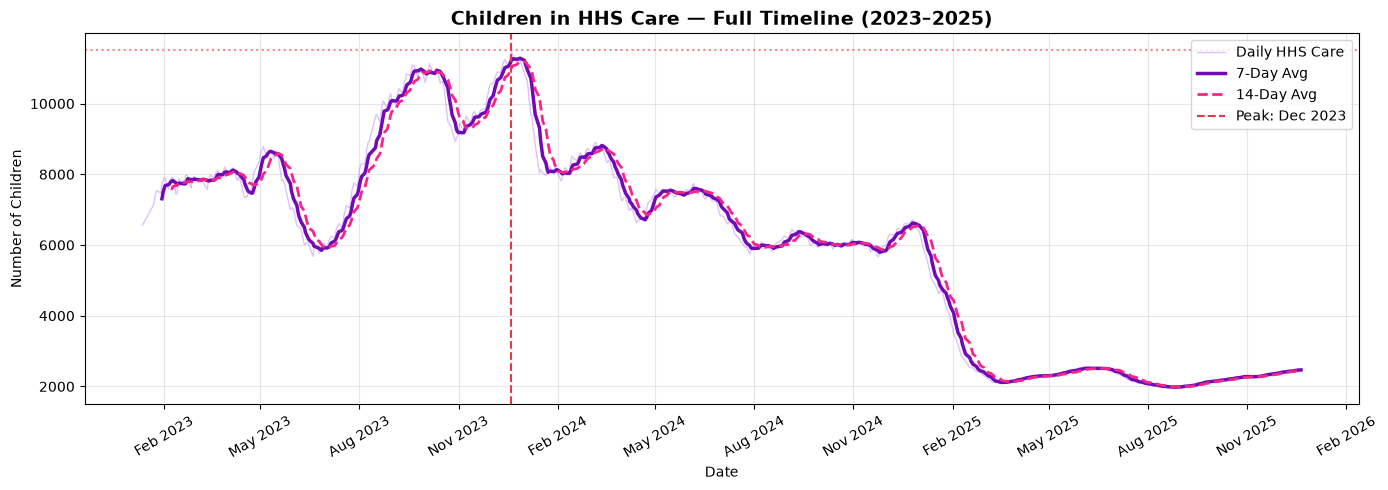

In [2]:
fig, ax = plt.subplots(figsize=(14, 5))

# raw daily values — light so it doesn't overpower the trend line
ax.plot(df["date"], df["hhs_care"],
        color="#c084fc", linewidth=1, alpha=0.5, label="Daily HHS Care")

# 7-day rolling average — the real trend line
ax.plot(df["date"], df["hhs_care_7day_avg"],
        color="#7209b7", linewidth=2.5, label="7-Day Avg")

# 14-day rolling average — slower moving, shows the bigger picture
ax.plot(df["date"], df["hhs_care_14day_avg"],
        color="#f72585", linewidth=2, linestyle="--", label="14-Day Avg")

ax.set_title("Children in HHS Care — Full Timeline (2023–2025)", fontsize=14, fontweight="bold")
ax.set_ylabel("Number of Children")
ax.set_xlabel("Date")
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30)

# vertical line at the peak HHS care date
peak_date = df.loc[df["hhs_care"].idxmax(), "date"]
peak_val  = df["hhs_care"].max()

ax.axvline(x=peak_date, color="#e63946", linewidth=1.5,
           linestyle="--", label=f"Peak: {peak_date.strftime('%b %Y')}")
ax.axhline(y=peak_val, color="#e63946", linewidth=1.5,
           linestyle=":", alpha=0.6)
ax.legend(loc="upper right") 

plt.tight_layout()
plt.savefig("../outputs/charts/01_hhs_care_trend.png", dpi=150)
plt.show()

### Chart 2: CBP Custody Over Time

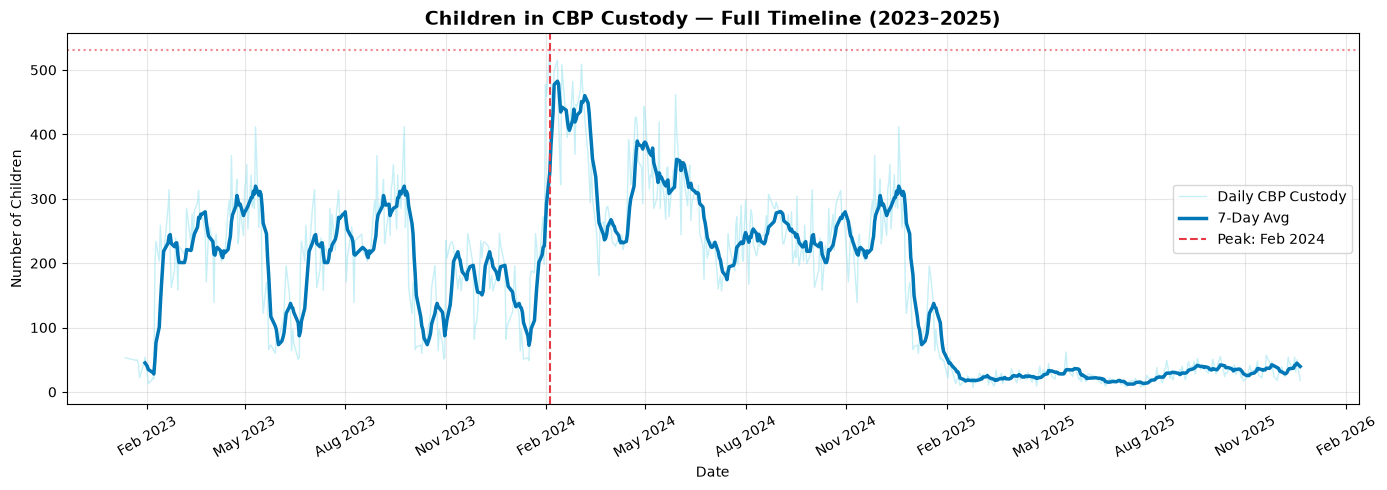

In [3]:
fig, ax = plt.subplots(figsize=(14, 5))

# daily CBP custody count
ax.plot(df["date"], df["cbp_custody"],
        color="#90e0ef", linewidth=1, alpha=0.5, label="Daily CBP Custody")

# 7-day rolling average
cbp_7day = df["cbp_custody"].rolling(7).mean()
ax.plot(df["date"], cbp_7day,
        color="#0077b6", linewidth=2.5, label="7-Day Avg")

ax.set_title("Children in CBP Custody — Full Timeline (2023–2025)", fontsize=14, fontweight="bold")
ax.set_ylabel("Number of Children")
ax.set_xlabel("Date")

ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30)

# vertical line at peak CBP custody date
peak_cbp_date = df.loc[df["cbp_custody"].idxmax(), "date"]
peak_cbp_val  = df["cbp_custody"].max()

ax.axvline(x=peak_cbp_date, color="#e63946", linewidth=1.5,
           linestyle="--", label=f"Peak: {peak_cbp_date.strftime('%b %Y')}")
ax.axhline(y=peak_cbp_val, color="#e63946", linewidth=1.5,
           linestyle=":", alpha=0.6)
ax.legend()

plt.tight_layout()
plt.savefig("../outputs/charts/02_cbp_custody_trend.png", dpi=150)
plt.show()

### Chart 3: HHS vs CBP Overlaid (shared axis)

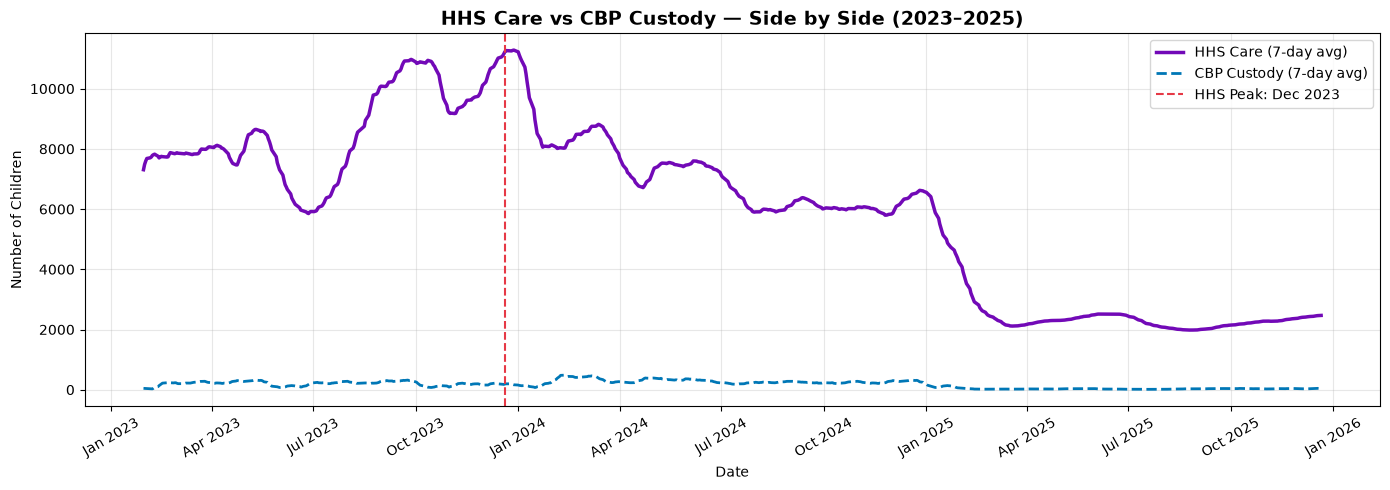

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))

# HHS care — primary metric, more prominent
ax.plot(df["date"], df["hhs_care_7day_avg"],
        color="#7209b7", linewidth=2.5, label="HHS Care (7-day avg)")

# CBP custody — secondary, thinner line
ax.plot(df["date"], cbp_7day,
        color="#0077b6", linewidth=2, linestyle="--", label="CBP Custody (7-day avg)")

ax.set_title("HHS Care vs CBP Custody — Side by Side (2023–2025)", fontsize=14, fontweight="bold")
ax.set_ylabel("Number of Children")
ax.set_xlabel("Date")
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30)

# only mark HHS peak — it's the primary metric
ax.axvline(x=peak_date, color="#e63946", linewidth=1.5,
           linestyle="--", label=f"HHS Peak: {peak_date.strftime('%b %Y')}")
ax.legend()

plt.tight_layout()
plt.savefig("../outputs/charts/03_hhs_vs_cbp_overlay.png", dpi=150)
plt.show()

### Chart 4: Monthly Average HHS Care (bar chart)

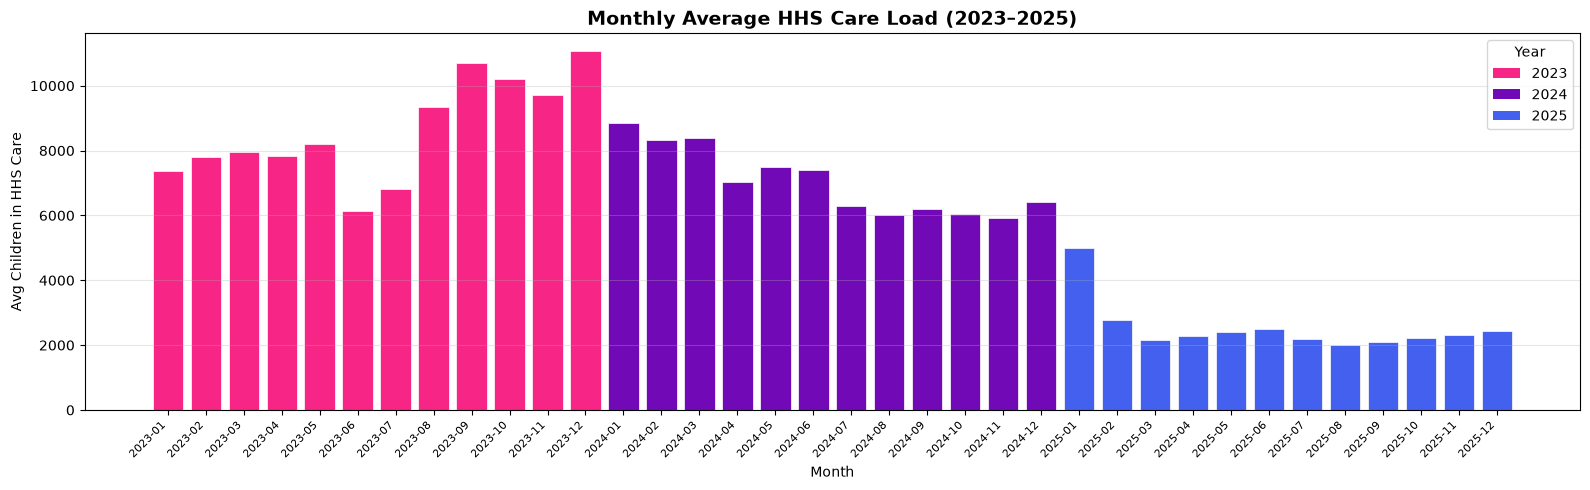

In [5]:
# group by year-month and take the mean HHS care load
df["year_month"] = df["date"].dt.to_period("M")
monthly_avg = df.groupby("year_month")["hhs_care"].mean().reset_index()
monthly_avg["year_month_str"] = monthly_avg["year_month"].astype(str)

# color each bar by year so the 3 years are visually distinct
year_colors = {
    "2023": "#f72585",
    "2024": "#7209b7",
    "2025": "#4361ee"
}
bar_colors = [year_colors[ym[:4]] for ym in monthly_avg["year_month_str"]]

fig, ax = plt.subplots(figsize=(16, 5))

bars = ax.bar(monthly_avg["year_month_str"], monthly_avg["hhs_care"],
              color=bar_colors, edgecolor="white", linewidth=0.5)

ax.set_title("Monthly Average HHS Care Load (2023–2025)", fontsize=14, fontweight="bold")
ax.set_ylabel("Avg Children in HHS Care")
ax.set_xlabel("Month")
plt.xticks(rotation=45, ha="right", fontsize=8)
ax.grid(axis="y", alpha=0.3)

# manual legend for the 3 years
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=y) for y, c in year_colors.items()]
ax.legend(handles=legend_elements, title="Year")

plt.tight_layout()
plt.savefig("../outputs/charts/04_monthly_avg_hhs.png", dpi=150)
plt.show()

### Chart 5: Total System Load Over Time

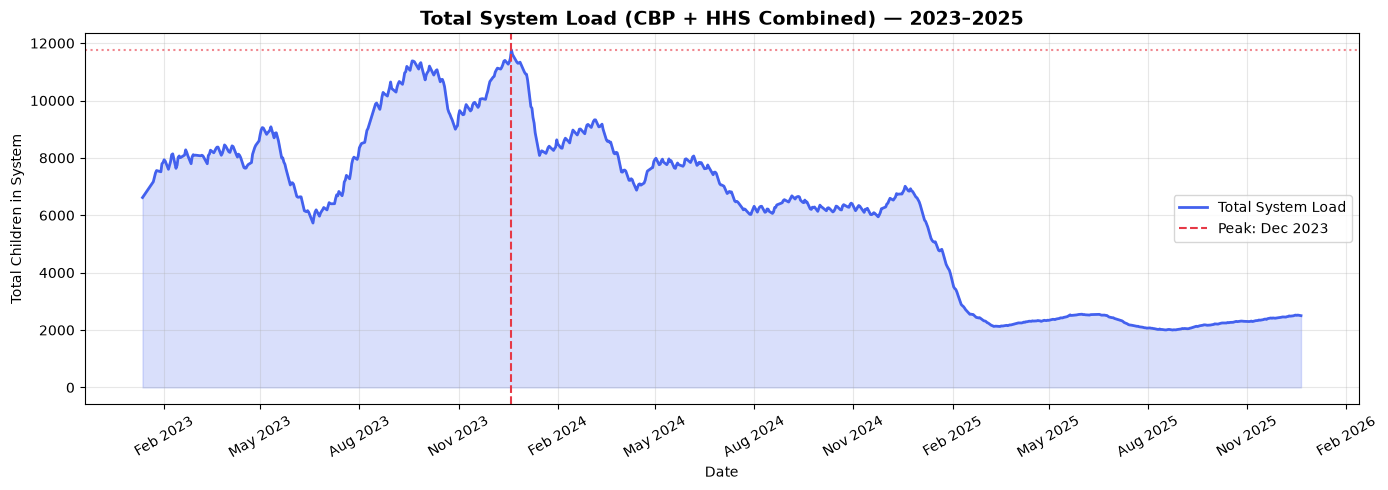

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))

# total system load = CBP + HHS combined
ax.fill_between(df["date"], df["total_system_load"],
                alpha=0.2, color="#4361ee", label="_nolegend_")

ax.plot(df["date"], df["total_system_load"],
        color="#4361ee", linewidth=2, label="Total System Load")

ax.set_title("Total System Load (CBP + HHS Combined) — 2023–2025", fontsize=14, fontweight="bold")
ax.set_ylabel("Total Children in System")
ax.set_xlabel("Date")
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30)

# vertical + horizontal at peak total load
peak_load_date = df.loc[df["total_system_load"].idxmax(), "date"]
peak_load_val  = df["total_system_load"].max()

ax.axvline(x=peak_load_date, color="#e63946", linewidth=1.5,
           linestyle="--", label=f"Peak: {peak_load_date.strftime('%b %Y')}")
ax.axhline(y=peak_load_val, color="#e63946", linewidth=1.5,
           linestyle=":", alpha=0.6)
ax.legend()

plt.tight_layout()
plt.savefig("../outputs/charts/05_total_system_load.png", dpi=150)
plt.show()

### Trend Summary (key numbers)

In [7]:
# compute year-wise averages for the paper
yearly = df.groupby(df["date"].dt.year)["hhs_care"].agg(["mean", "max", "min"])
yearly.index.name = "year"
yearly.columns = ["avg_hhs_care", "peak_hhs_care", "lowest_hhs_care"]

print("TREND SUMMARY BY YEAR: \n")
print(yearly.round(0).to_string())

# overall direction — compare first month avg vs last month avg
first_month_avg = df[df["date"].dt.year == 2023]["hhs_care"].mean()
last_month_avg  = df[df["date"].dt.year == 2025]["hhs_care"].mean()
change_pct = ((last_month_avg - first_month_avg) / first_month_avg) * 100

print(f"\nOverall direction:")
print(f"  2023 avg HHS care: {first_month_avg:,.0f} children")
print(f"  2025 avg HHS care: {last_month_avg:,.0f} children")
print(f"  Change:            {change_pct:.1f}%  ({'decrease' if change_pct < 0 else 'increase'})")

TREND SUMMARY BY YEAR: 

      avg_hhs_care  peak_hhs_care  lowest_hhs_care
year                                              
2023        8646.0          11516             5679
2024        7043.0          10870             5664
2025        2543.0           6405             1972

Overall direction:
  2023 avg HHS care: 8,646 children
  2025 avg HHS care: 2,543 children
  Change:            -70.6%  (decrease)


In [8]:
import json

# build the json structure
trend_summary = {
    "yearly_stats": yearly.round(0).astype(int).to_dict(orient="index"),
    "overall_direction": {
        "avg_2023": round(first_month_avg, 0),
        "avg_2025": round(last_month_avg, 0),
        "change_pct": round(change_pct, 1),
        "direction": "decrease" if change_pct < 0 else "increase"
    }
}

# save to outputs/reports/
output_path = "../outputs/reports/trend_summary.json"
with open(output_path, "w") as f:
    json.dump(trend_summary, f, indent=2)

print(f"\nSaved to {output_path}")


Saved to ../outputs/reports/trend_summary.json


---
## Section 2 — CBP vs HHS Comparison

Comparing the flow INTO HHS (transfers from CBP) against
the flow OUT of HHS (discharges to sponsors).

Key questions:
- Are discharges keeping up with incoming transfers?
- When is HHS absorbing more than it can release?
- What does the transfer-to-discharge ratio look like over time?
---

### Chart 6: Daily Transfers vs Discharges Over Time

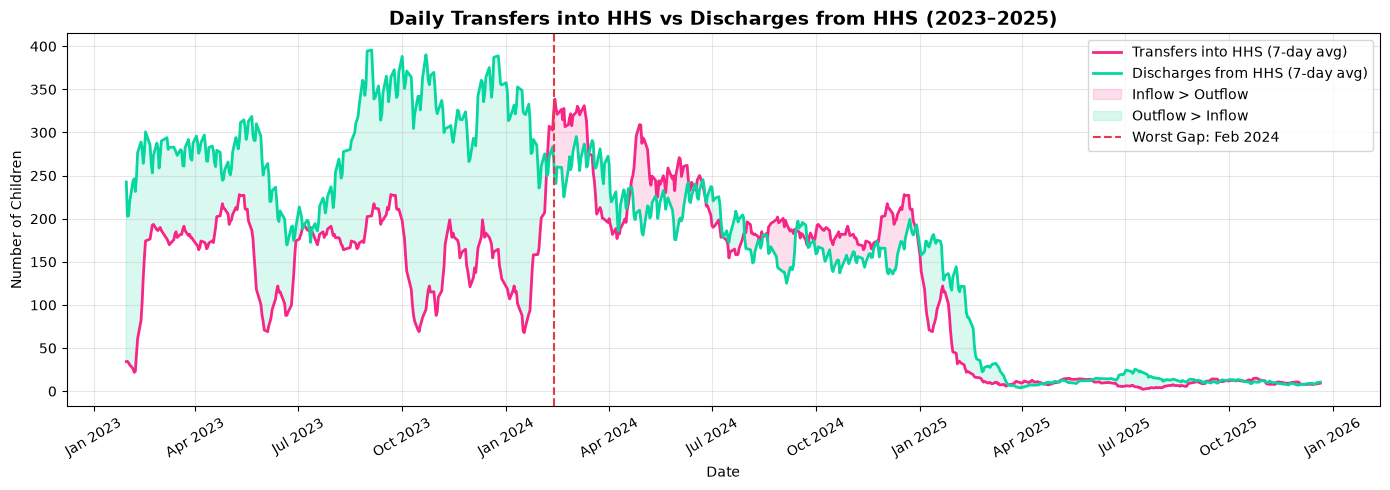

In [9]:
# 7-day rolling averages to smooth the noise
transfers_7day  = df["cbp_transferred"].rolling(7).mean()
discharges_7day = df["hhs_discharged"].rolling(7).mean()

fig, ax = plt.subplots(figsize=(14, 5))

# transfers into HHS — the inflow
ax.plot(df["date"], transfers_7day,
        color="#f72585", linewidth=2, label="Transfers into HHS (7-day avg)")

# discharges from HHS — the outflow
ax.plot(df["date"], discharges_7day,
        color="#06d6a0", linewidth=2, label="Discharges from HHS (7-day avg)")

# shade the gap between the two lines
# red fill = inflow > outflow (system filling up)
# green fill = outflow > inflow (system draining)
ax.fill_between(df["date"], transfers_7day, discharges_7day,
                where=(transfers_7day >= discharges_7day),
                alpha=0.15, color="#f72585", label="Inflow > Outflow")
ax.fill_between(df["date"], transfers_7day, discharges_7day,
                where=(transfers_7day < discharges_7day),
                alpha=0.15, color="#06d6a0", label="Outflow > Inflow")

ax.set_title("Daily Transfers into HHS vs Discharges from HHS (2023–2025)",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Number of Children")
ax.set_xlabel("Date")
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30)

# mark the date where transfer-discharge gap was largest (worst imbalance)
df["transfer_discharge_gap"] = df["cbp_transferred"] - df["hhs_discharged"]
worst_gap_date = df.loc[df["transfer_discharge_gap"].idxmax(), "date"]

ax.axvline(x=worst_gap_date, color="#e63946", linewidth=1.5,
           linestyle="--", label=f"Worst Gap: {worst_gap_date.strftime('%b %Y')}")
ax.legend()

plt.tight_layout()
plt.savefig("../outputs/charts/06_transfers_vs_discharges.png", dpi=150)
plt.show()

### Chart 7: Discharge Offset Ratio Over Time

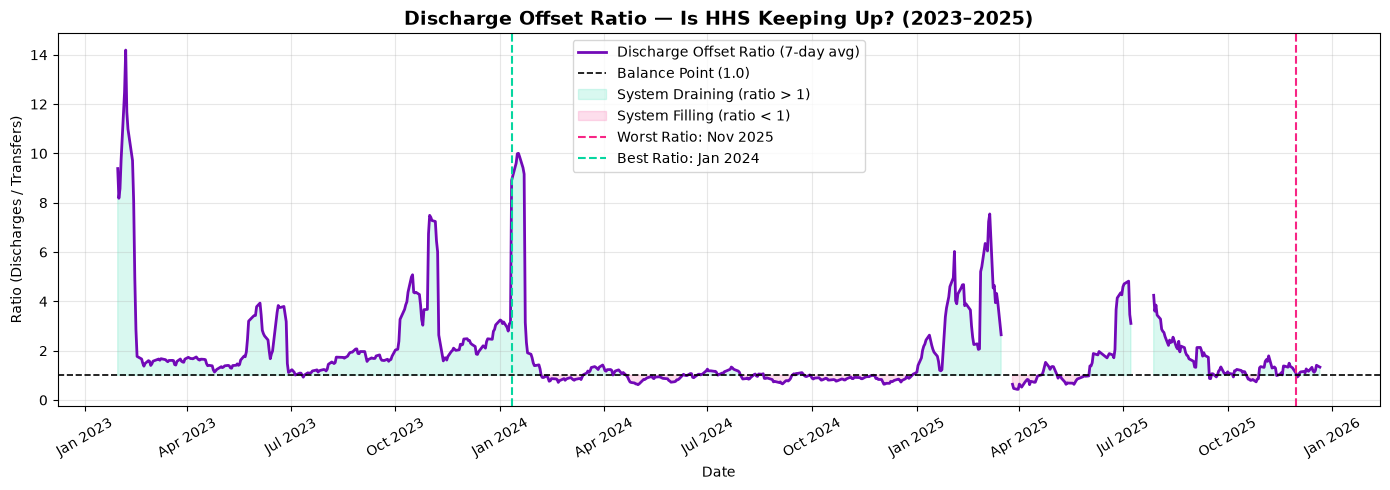

In [10]:
# discharge offset ratio = discharges / transfers
# > 1.0 means HHS is releasing more than it receives — system draining
# < 1.0 means HHS is receiving more than it releases — system filling
# = 1.0 means perfectly balanced

df["discharge_offset_ratio"] = df["hhs_discharged"] / df["cbp_transferred"].replace(0, np.nan)
ratio_7day = df["discharge_offset_ratio"].rolling(7).mean()

fig, ax = plt.subplots(figsize=(14, 5))

# color the line by whether ratio is above or below 1
ax.plot(df["date"], ratio_7day,
        color="#7209b7", linewidth=2, label="Discharge Offset Ratio (7-day avg)")

# reference line at 1.0 — the balance point
ax.axhline(y=1.0, color="black", linewidth=1.2, linestyle="--", label="Balance Point (1.0)")

# shade above and below the balance line
ax.fill_between(df["date"], ratio_7day, 1,
                where=(ratio_7day >= 1),
                alpha=0.15, color="#06d6a0", label="System Draining (ratio > 1)")
ax.fill_between(df["date"], ratio_7day, 1,
                where=(ratio_7day < 1),
                alpha=0.15, color="#f72585", label="System Filling (ratio < 1)")

ax.set_title("Discharge Offset Ratio — Is HHS Keeping Up? (2023–2025)",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Ratio (Discharges / Transfers)")
ax.set_xlabel("Date")
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30)

# mark the lowest ratio (worst filling period) and highest ratio (best draining period)
# ignore NaN rows for idxmin/idxmax
valid_ratio = df["discharge_offset_ratio"].dropna()

worst_ratio_date = df.loc[valid_ratio.idxmin(), "date"]
best_ratio_date  = df.loc[valid_ratio.idxmax(), "date"]

ax.axvline(x=worst_ratio_date, color="#f72585", linewidth=1.5,
           linestyle="--", label=f"Worst Ratio: {worst_ratio_date.strftime('%b %Y')}")
ax.axvline(x=best_ratio_date, color="#06d6a0", linewidth=1.5,
           linestyle="--", label=f"Best Ratio: {best_ratio_date.strftime('%b %Y')}")
ax.legend()

plt.tight_layout()
plt.savefig("../outputs/charts/07_discharge_offset_ratio.png", dpi=150)
plt.show()

### Chart 8: Monthly Transfers vs Discharges (grouped bar)

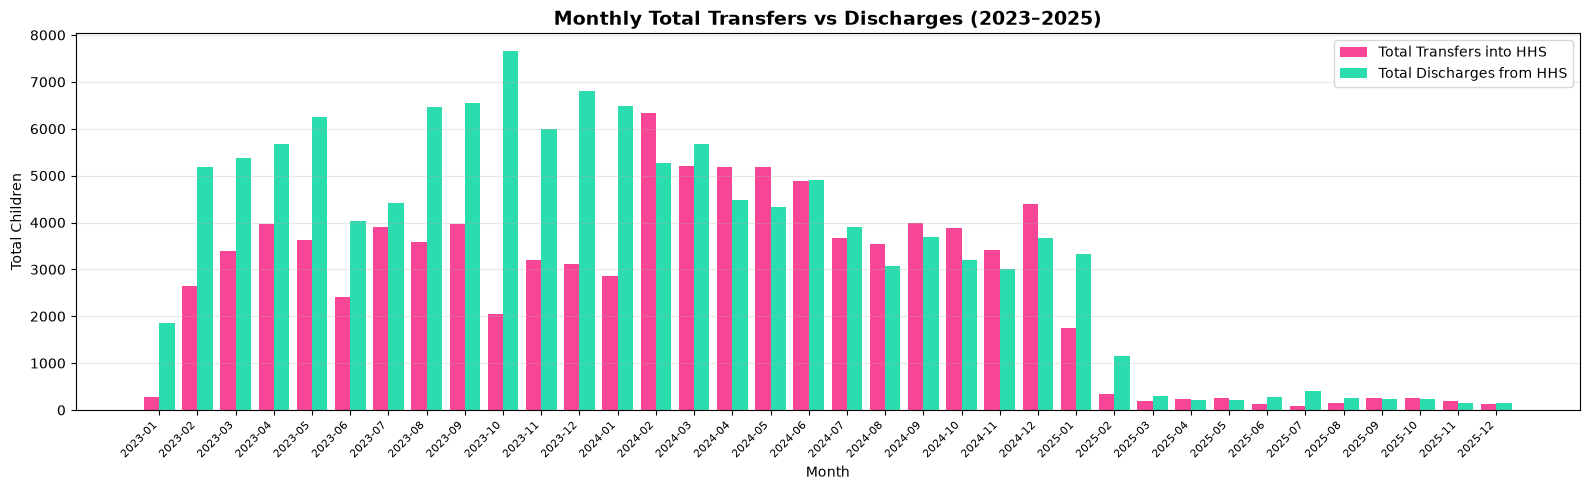

In [11]:
# monthly totals — more meaningful than daily for comparing inflow vs outflow
monthly_flow = df.groupby("year_month").agg(
    total_transfers=("cbp_transferred", "sum"),
    total_discharges=("hhs_discharged", "sum")
).reset_index()

monthly_flow["year_month_str"] = monthly_flow["year_month"].astype(str)

x = np.arange(len(monthly_flow))
bar_width = 0.4

fig, ax = plt.subplots(figsize=(16, 5))

ax.bar(x - bar_width/2, monthly_flow["total_transfers"],
       width=bar_width, color="#f72585", alpha=0.85, label="Total Transfers into HHS")
ax.bar(x + bar_width/2, monthly_flow["total_discharges"],
       width=bar_width, color="#06d6a0", alpha=0.85, label="Total Discharges from HHS")

ax.set_title("Monthly Total Transfers vs Discharges (2023–2025)",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Total Children")
ax.set_xlabel("Month")
ax.set_xticks(x)
ax.set_xticklabels(monthly_flow["year_month_str"], rotation=45, ha="right", fontsize=8)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/charts/08_monthly_transfers_vs_discharges.png", dpi=150)
plt.show()

### Chart 9: Scatter — Transfers vs Discharges (correlation)

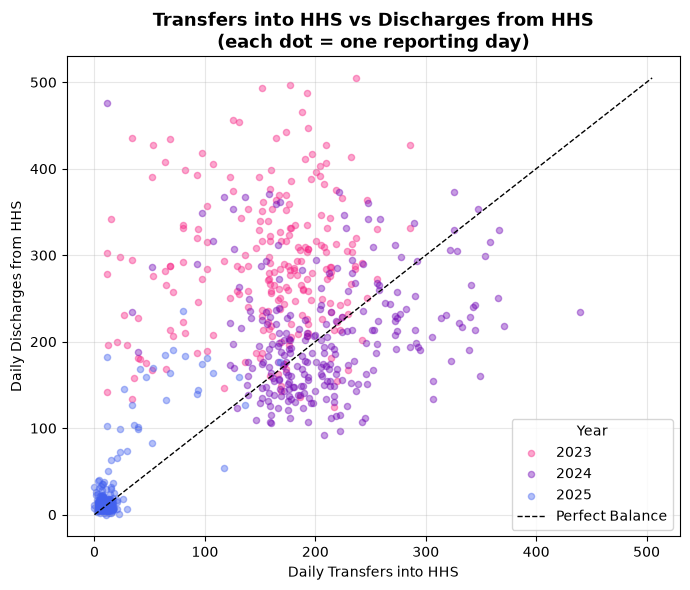

In [12]:
# are days with high transfers also days with high discharges?
# color by year to see if the relationship changed over time

year_palette = {2023: "#f72585", 2024: "#7209b7", 2025: "#4361ee"}
df["year"] = df["date"].dt.year

fig, ax = plt.subplots(figsize=(7, 6))

for year, color in year_palette.items():
    subset = df[df["year"] == year]
    ax.scatter(subset["cbp_transferred"], subset["hhs_discharged"],
               color=color, alpha=0.4, s=20, label=str(year))

# diagonal reference line — if dots fall on this, transfers = discharges exactly
max_val = max(df["cbp_transferred"].max(), df["hhs_discharged"].max())
ax.plot([0, max_val], [0, max_val],
        color="black", linewidth=1, linestyle="--", label="Perfect Balance")

ax.set_title("Transfers into HHS vs Discharges from HHS\n(each dot = one reporting day)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Daily Transfers into HHS")
ax.set_ylabel("Daily Discharges from HHS")
ax.legend(title="Year")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/charts/09_transfer_discharge_scatter.png", dpi=150)
plt.show()

### CBP vs HHS Summary Stats

In [13]:
# yearly breakdown of inflow vs outflow
yearly_flow = df.groupby("year").agg(
    avg_daily_transfers=("cbp_transferred",  "mean"),
    avg_daily_discharges=("hhs_discharged",  "mean"),
    avg_offset_ratio=("discharge_offset_ratio", "mean")
).round(1)

print(" CBP → HHS FLOW SUMMARY BY YEAR \n")
print(yearly_flow.to_string())

# overall: how often was system draining vs filling?
draining_days = (df["discharge_offset_ratio"] >= 1).sum()
filling_days  = (df["discharge_offset_ratio"] <  1).sum()
total_days    = draining_days + filling_days

print(f"\nOut of {total_days} reporting days:")
print(f"  System draining (discharges ≥ transfers): {draining_days} days ({draining_days/total_days*100:.1f}%)")
print(f"  System filling  (transfers > discharges): {filling_days} days  ({filling_days/total_days*100:.1f}%)")

# correlation between transfers and discharges
corr = df["cbp_transferred"].corr(df["hhs_discharged"])
print(f"\nCorrelation between daily transfers and discharges: {corr:.3f}")
print("(1.0 = perfectly in sync, 0 = no relationship)")

 CBP → HHS FLOW SUMMARY BY YEAR 

      avg_daily_transfers  avg_daily_discharges  avg_offset_ratio
year                                                             
2023                157.1                 288.0               2.7
2024                209.4                 205.9               1.3
2025                 16.6                  29.0               2.2

Out of 717 reporting days:
  System draining (discharges ≥ transfers): 479 days (66.8%)
  System filling  (transfers > discharges): 238 days  (33.2%)

Correlation between daily transfers and discharges: 0.657
(1.0 = perfectly in sync, 0 = no relationship)


In [14]:
# build the json structure
flow_summary = {
    "yearly_flow": yearly_flow.to_dict(orient="index"),
    "system_balance": {
        "total_reporting_days": int(total_days),
        "draining_days": int(draining_days),
        "draining_pct": round(draining_days / total_days * 100, 1),
        "filling_days": int(filling_days),
        "filling_pct": round(filling_days / total_days * 100, 1)
    },
    "transfer_discharge_correlation": round(corr, 3)
}

# save to outputs/reports/
output_path = "../outputs/reports/flow_summary.json"
with open(output_path, "w") as f:
    json.dump(flow_summary, f, indent=2)

print(f"\nSaved to {output_path}")


Saved to ../outputs/reports/flow_summary.json


---
## Section 3 — Stress & Pressure Periods

Identifying when the system was under the most strain.
A "stress period" is when care load stayed dangerously high
for multiple consecutive days — not just a single spike.

Key questions:
- Which days were in the top 10% of system load?
- Which months had sustained high-load windows?
- How long did the worst stress periods last?
---

### Define Stress Threshold

In [15]:
# stress threshold = top 10% of all HHS care load values
# any day above this line is considered a "high stress" day
stress_threshold = df["hhs_care"].quantile(0.90)

# count how many days crossed that threshold
stress_days = df[df["hhs_care"] >= stress_threshold]

print(f"Stress threshold (90th percentile): {stress_threshold:,.0f} children")
print(f"Total high-stress days:             {len(stress_days)} days")
print(f"Date range of stress days:          {stress_days['date'].min().date()} → {stress_days['date'].max().date()}")

Stress threshold (90th percentile): 9,762 children
Total high-stress days:             73 days
Date range of stress days:          2023-08-22 → 2024-01-04


### Chart 10: HHS Care with Stress Zone Highlighted

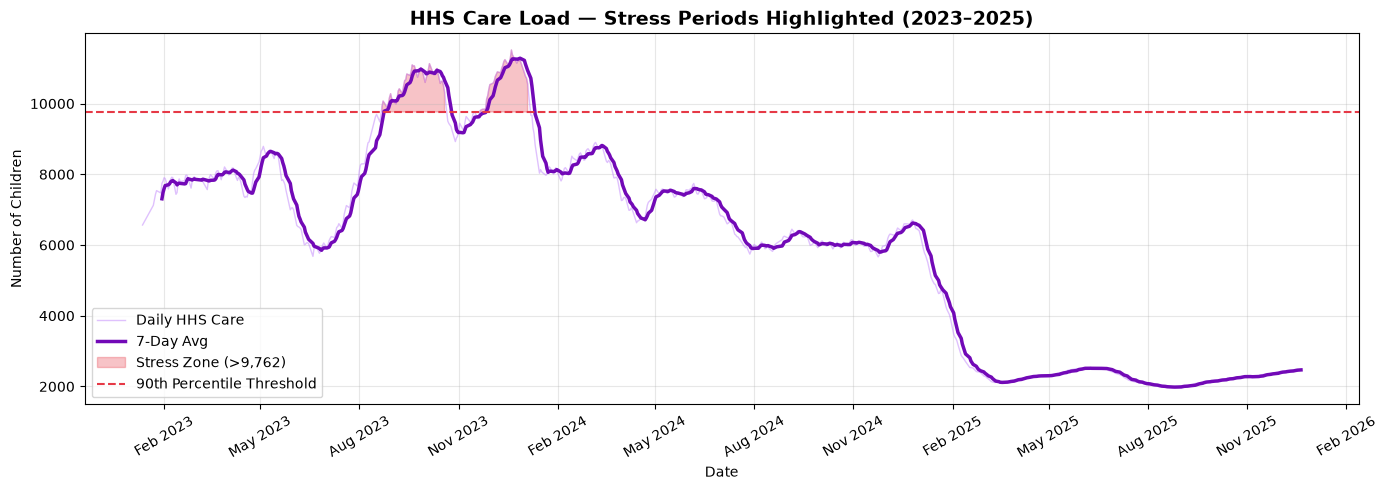

In [16]:
fig, ax = plt.subplots(figsize=(14, 5))

# full HHS care line
ax.plot(df["date"], df["hhs_care"],
        color="#c084fc", linewidth=1, alpha=0.5, label="Daily HHS Care")

# 7-day avg trend line
ax.plot(df["date"], df["hhs_care_7day_avg"],
        color="#7209b7", linewidth=2.5, label="7-Day Avg")

# red fill above the stress threshold — the danger zone
ax.fill_between(df["date"], df["hhs_care"], stress_threshold,
                where=(df["hhs_care"] >= stress_threshold),
                color="#e63946", alpha=0.3, label=f"Stress Zone (>{stress_threshold:,.0f})")

# horizontal line at the threshold
ax.axhline(y=stress_threshold, color="#e63946", linewidth=1.5,
           linestyle="--", label="90th Percentile Threshold")

ax.set_title("HHS Care Load — Stress Periods Highlighted (2023–2025)",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Number of Children")
ax.set_xlabel("Date")
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig("../outputs/charts/10_stress_zone_hhs.png", dpi=150)
plt.show()

### Chart 11: Total System Load with Stress Zone

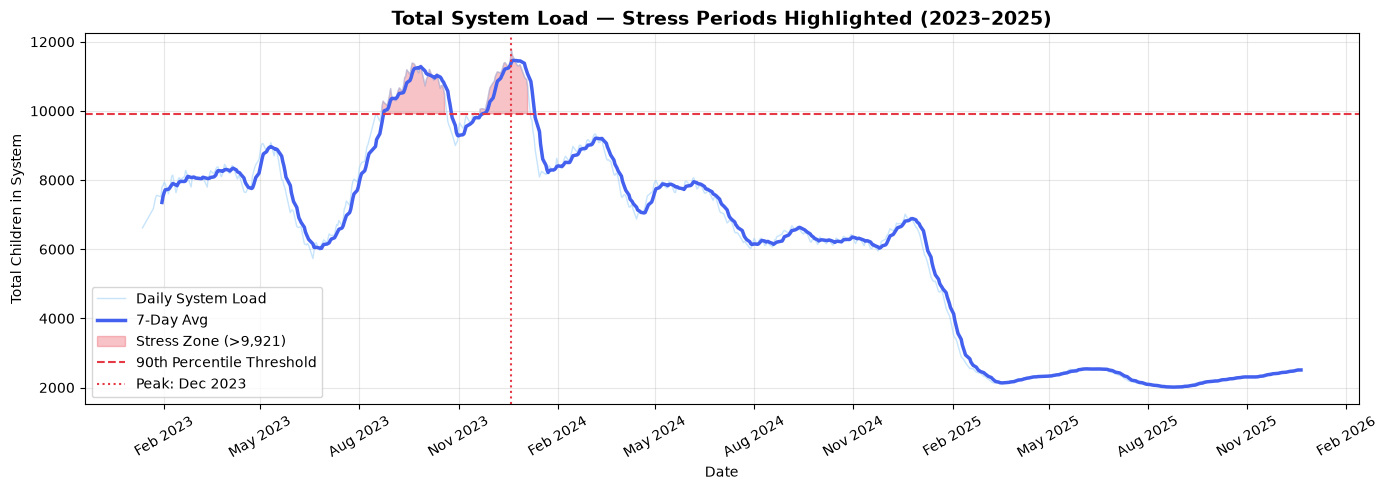

In [17]:
# same idea but for total system load (CBP + HHS combined)
system_threshold = df["total_system_load"].quantile(0.90)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df["date"], df["total_system_load"],
        color="#90caf9", linewidth=1, alpha=0.5, label="Daily System Load")

system_7day = df["total_system_load"].rolling(7).mean()
ax.plot(df["date"], system_7day,
        color="#4361ee", linewidth=2.5, label="7-Day Avg")

ax.fill_between(df["date"], df["total_system_load"], system_threshold,
                where=(df["total_system_load"] >= system_threshold),
                color="#e63946", alpha=0.3, label=f"Stress Zone (>{system_threshold:,.0f})")

ax.axhline(y=system_threshold, color="#e63946", linewidth=1.5,
           linestyle="--", label="90th Percentile Threshold")

# peak total load marker
peak_load_date = df.loc[df["total_system_load"].idxmax(), "date"]
ax.axvline(x=peak_load_date, color="#e63946", linewidth=1.5,
           linestyle=":", label=f"Peak: {peak_load_date.strftime('%b %Y')}")

ax.set_title("Total System Load — Stress Periods Highlighted (2023–2025)",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Total Children in System")
ax.set_xlabel("Date")
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig("../outputs/charts/11_stress_zone_total_load.png", dpi=150)
plt.show()

### Chart 12: Sustained Stress Windows (consecutive high-load days)

In [18]:
# find consecutive runs of high-stress days
# this is more meaningful than individual spikes —
# 30 straight days above threshold is far worse than 30 scattered days

df["is_stress_day"] = (df["hhs_care"] >= stress_threshold).astype(int)

# label each consecutive stress block with a group number
df["stress_group"] = (df["is_stress_day"] != df["is_stress_day"].shift()).cumsum()

# keep only the stress days and find how long each block lasted
stress_blocks = (
    df[df["is_stress_day"] == 1]
    .groupby("stress_group")
    .agg(
        start_date=("date", "first"),
        end_date=("date", "last"),
        duration_days=("date", "count"),
        avg_load=("hhs_care", "mean"),
        peak_load=("hhs_care", "max")
    )
    .reset_index(drop=True)
    .sort_values("duration_days", ascending=False)
)

print(f"Total sustained stress windows: {len(stress_blocks)}")
print(f"\nTop 10 longest stress windows:")
print(stress_blocks.head(10).to_string(index=False))

Total sustained stress windows: 3

Top 10 longest stress windows:
start_date   end_date  duration_days     avg_load  peak_load
2023-08-22 2023-10-19             41 10595.073171      11130
2023-11-21 2024-01-04             30 10799.566667      11516
2023-11-15 2023-11-16              2  9762.000000       9762


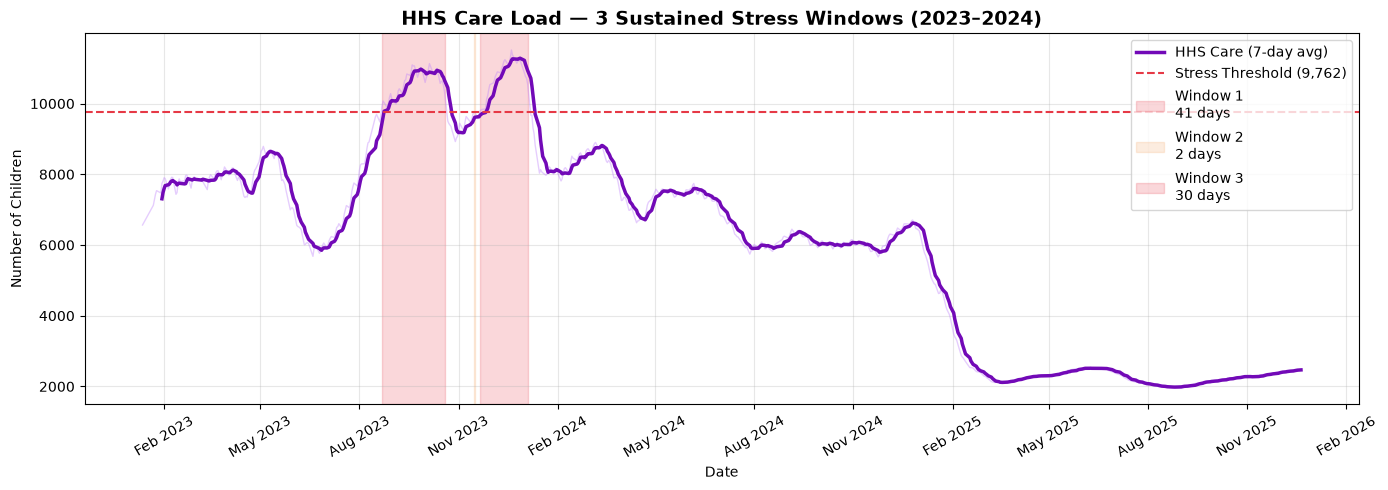

In [19]:
# with only 3 windows, the most powerful visualization is showing them
# directly on the care load chart as shaded bands with labels

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df["date"], df["hhs_care"],
        color="#c084fc", linewidth=1, alpha=0.4)
ax.plot(df["date"], df["hhs_care_7day_avg"],
        color="#7209b7", linewidth=2.5, label="HHS Care (7-day avg)")

ax.axhline(y=stress_threshold, color="#e63946", linewidth=1.5,
           linestyle="--", label=f"Stress Threshold ({stress_threshold:,.0f})")

# shade each of the 3 windows directly on the timeline
window_labels = ["Window 1\n41 days", "Window 2\n2 days", "Window 3\n30 days"]
window_colors = ["#e63946", "#f4a261", "#e63946"]

for i, (_, row) in enumerate(stress_blocks.sort_values("start_date").iterrows()):
    ax.axvspan(row["start_date"], row["end_date"],
               alpha=0.2, color=window_colors[i], label=window_labels[i])

ax.set_title("HHS Care Load — 3 Sustained Stress Windows (2023–2024)",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Number of Children")
ax.set_xlabel("Date")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig("../outputs/charts/12_stress_windows_annotated.png", dpi=150)
plt.show()

### Chart 13: Care Load Volatility (rolling std dev)

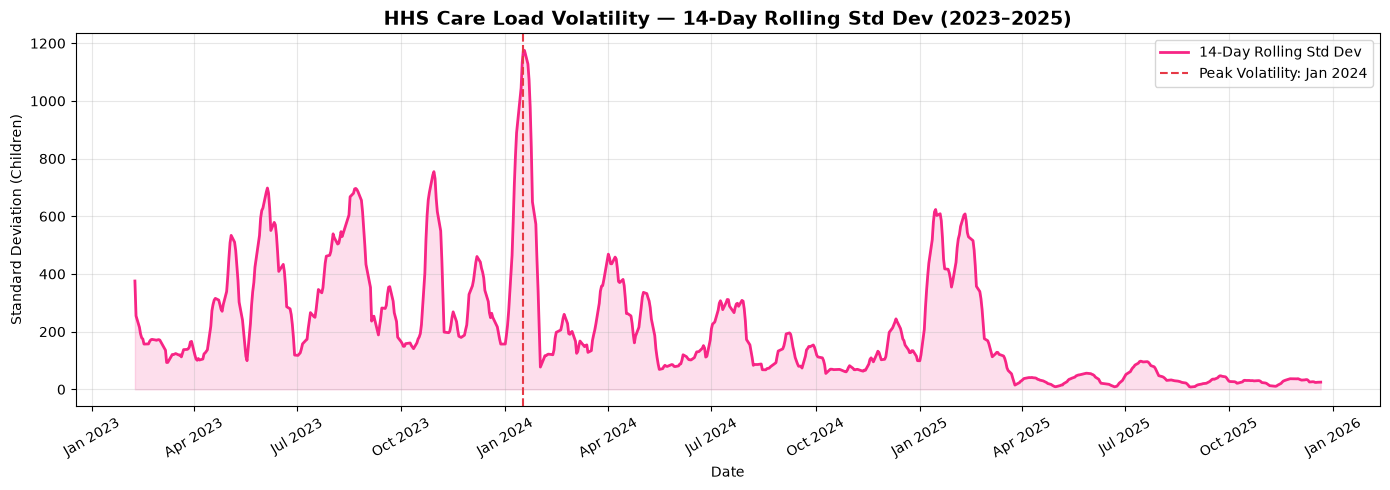

In [20]:
# volatility = how wildly the care load swings day to day
# high volatility = unpredictable system = hard to staff and plan for
# use a 14-day rolling standard deviation

df["volatility_14day"] = df["hhs_care"].rolling(14).std()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df["date"], df["volatility_14day"],
        color="#f72585", linewidth=2, label="14-Day Rolling Std Dev")

ax.fill_between(df["date"], df["volatility_14day"],
                alpha=0.15, color="#f72585")

# peak volatility marker
peak_vol_date = df.loc[df["volatility_14day"].idxmax(), "date"]
ax.axvline(x=peak_vol_date, color="#e63946", linewidth=1.5,
           linestyle="--", label=f"Peak Volatility: {peak_vol_date.strftime('%b %Y')}")

ax.set_title("HHS Care Load Volatility — 14-Day Rolling Std Dev (2023–2025)",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Standard Deviation (Children)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig("../outputs/charts/13_care_load_volatility.png", dpi=150)
plt.show()

### Stress Period Summary

In [21]:
# numbers that go directly into your paper
total_stress_days = df["is_stress_day"].sum()
total_days        = len(df)
longest_window    = stress_blocks.iloc[0]

print(" STRESS PERIOD SUMMARY \n")
print(f"Stress threshold:          {stress_threshold:,.0f} children (90th percentile)")
print(f"Total high-stress days:    {total_stress_days} of {total_days} ({total_stress_days/total_days*100:.1f}%)")
print(f"Total stress windows:      {len(stress_blocks)}")
print(f"\nLongest sustained window:")
print(f"  Start:     {longest_window['start_date'].date()}")
print(f"  End:       {longest_window['end_date'].date()}")
print(f"  Duration:  {longest_window['duration_days']} consecutive reporting days")
print(f"  Avg load:  {longest_window['avg_load']:,.0f} children")
print(f"  Peak load: {longest_window['peak_load']:,.0f} children")

# year-wise breakdown
yearly_stress = df.groupby("year")["is_stress_day"].agg(["sum", "count"])
yearly_stress["stress_pct"] = (yearly_stress["sum"] / yearly_stress["count"] * 100).round(1)
yearly_stress.columns = ["stress_days", "total_days", "stress_pct"]
print(f"\nStress days by year:")
print(yearly_stress.to_string())

 STRESS PERIOD SUMMARY 

Stress threshold:          9,762 children (90th percentile)
Total high-stress days:    73 of 720 (10.1%)
Total stress windows:      3

Longest sustained window:
  Start:     2023-08-22
  End:       2023-10-19
  Duration:  41 consecutive reporting days
  Avg load:  10,595 children
  Peak load: 11,130 children

Stress days by year:
      stress_days  total_days  stress_pct
year                                     
2023           69         230        30.0
2024            4         251         1.6
2025            0         239         0.0


In [22]:
# build the json structure
stress_summary = {
    "threshold": {
        "value": round(float(stress_threshold), 0),
        "method": "90th percentile of all HHS care values"
    },
    "overall": {
        "total_stress_days": int(total_stress_days),
        "total_reporting_days": int(total_days),
        "stress_pct": round(total_stress_days / total_days * 100, 1),
        "total_stress_windows": len(stress_blocks)
    },
    "longest_window": {
        "start_date": str(longest_window["start_date"].date()),
        "end_date":   str(longest_window["end_date"].date()),
        "duration_days": int(longest_window["duration_days"]),
        "avg_load":  round(float(longest_window["avg_load"]), 0),
        "peak_load": round(float(longest_window["peak_load"]), 0)
    },
    "all_windows": [
        {
            "start_date":    str(row["start_date"].date()),
            "end_date":      str(row["end_date"].date()),
            "duration_days": int(row["duration_days"]),
            "avg_load":      round(float(row["avg_load"]), 0),
            "peak_load":     round(float(row["peak_load"]), 0)
        }
        for _, row in stress_blocks.iterrows()
    ],
    "yearly_breakdown": yearly_stress[["stress_days", "total_days", "stress_pct"]]
                            .astype({"stress_days": int, "total_days": int})
                            .to_dict(orient="index")
}

# save to outputs/reports/
output_path = "../outputs/reports/stress_summary.json"
with open(output_path, "w") as f:
    json.dump(stress_summary, f, indent=2)

print(f"\nSaved to {output_path}")


Saved to ../outputs/reports/stress_summary.json


---
## Section 4 — Net Intake & Backlog

Analyzing whether more children are entering HHS than leaving,
and whether that imbalance is building into a long-term backlog.

Net Daily Intake = Transfers into HHS − Discharges from HHS
Positive = system filling up | Negative = system draining

Key questions:
- When was the system absorbing more than it could release?
- Did the backlog ever reverse? When and how fast?
- How does cumulative pressure look across the full timeline?
---

### Chart 14: Daily Net Intake (bar chart)

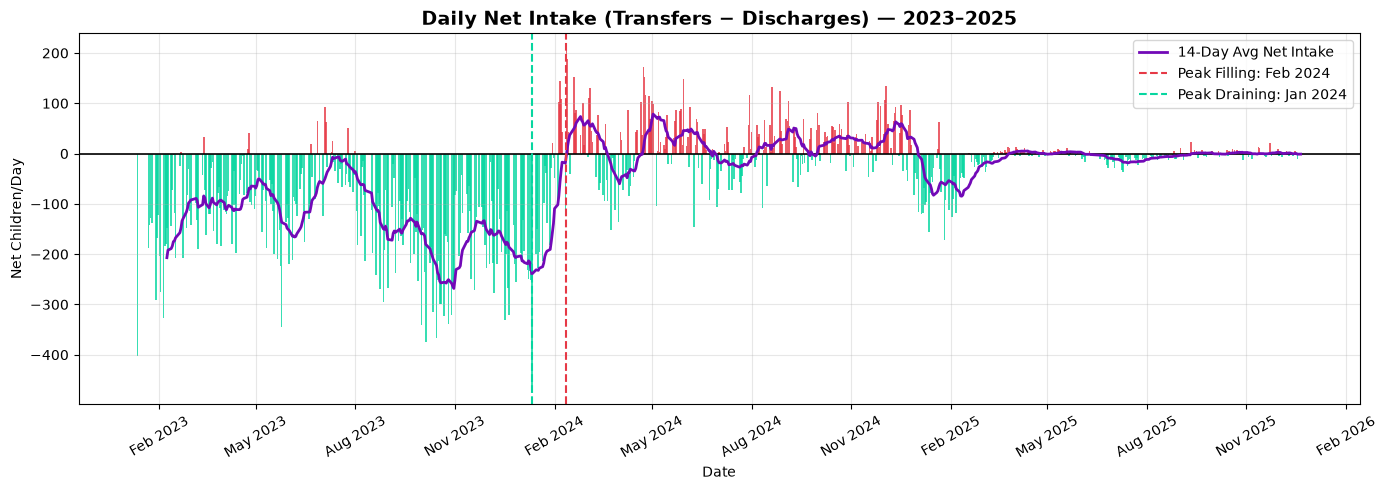

In [23]:
fig, ax = plt.subplots(figsize=(14, 5))

# color each bar — red means filling up, green means draining
bar_colors = ["#e63946" if v > 0 else "#06d6a0" for v in df["net_daily_intake"]]

ax.bar(df["date"], df["net_daily_intake"],
       color=bar_colors, width=1.5, alpha=0.8)

# reference line at zero — the balance point
ax.axhline(y=0, color="black", linewidth=1.2)

# 14-day rolling average to show the underlying trend
net_14day = df["net_daily_intake"].rolling(14).mean()
ax.plot(df["date"], net_14day,
        color="#7209b7", linewidth=2, label="14-Day Avg Net Intake")

# peak filling and peak draining markers
peak_fill_date  = df.loc[df["net_daily_intake"].idxmax(), "date"]
peak_drain_date = df.loc[df["net_daily_intake"].idxmin(), "date"]

ax.axvline(x=peak_fill_date, color="#e63946", linewidth=1.5,
           linestyle="--", label=f"Peak Filling: {peak_fill_date.strftime('%b %Y')}")
ax.axvline(x=peak_drain_date, color="#06d6a0", linewidth=1.5,
           linestyle="--", label=f"Peak Draining: {peak_drain_date.strftime('%b %Y')}")

ax.set_title("Daily Net Intake (Transfers − Discharges) — 2023–2025",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Net Children/Day")
ax.set_xlabel("Date")
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig("../outputs/charts/14_daily_net_intake.png", dpi=150)
plt.show()

### Chart 15: Cumulative Net Intake (backlog buildup)

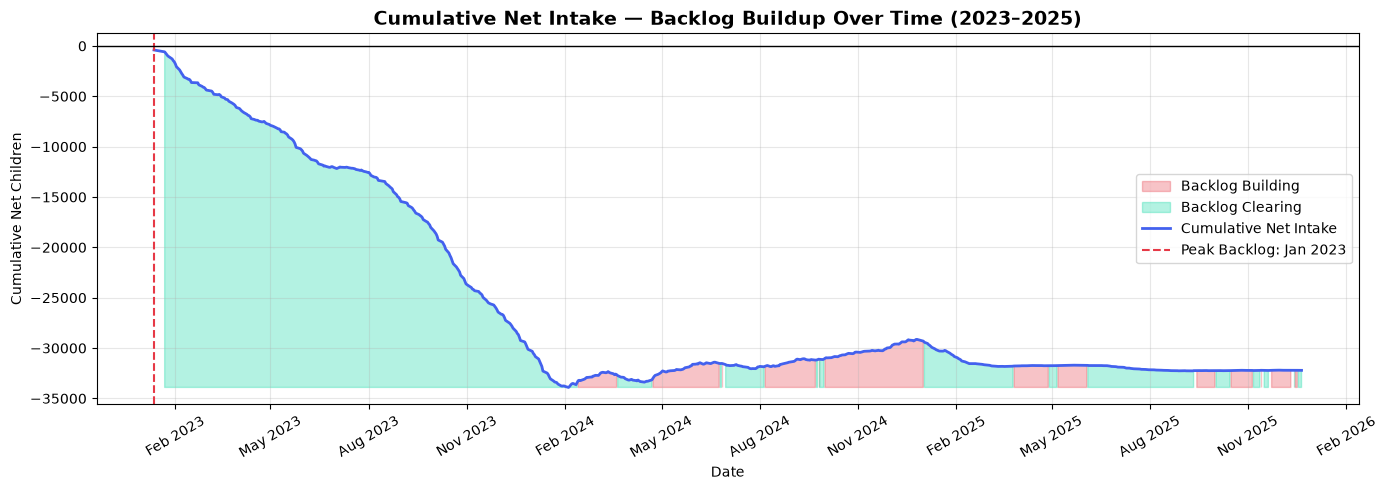

In [24]:
fig, ax = plt.subplots(figsize=(14, 5))

# shade by local trend (14-day rolling change), not by the absolute sign of the
# cumulative total -- the running total is negative for almost the entire
# timeline, so shading by its raw sign would make "Backlog Building" invisible
# even during stretches where the backlog was actively re-growing
backlog_trend = df["cumulative_net_intake"].diff().rolling(14, min_periods=1).mean()

ax.fill_between(df["date"], df["cumulative_net_intake"], df["cumulative_net_intake"].min(),
                where=(backlog_trend >= 0),
                color="#e63946", alpha=0.3, label="Backlog Building")
ax.fill_between(df["date"], df["cumulative_net_intake"], df["cumulative_net_intake"].min(),
                where=(backlog_trend < 0),
                color="#06d6a0", alpha=0.3, label="Backlog Clearing")

ax.plot(df["date"], df["cumulative_net_intake"],
        color="#4361ee", linewidth=2, label="Cumulative Net Intake")

# mark the peak backlog point — when pressure was at its worst
peak_backlog_date = df.loc[df["cumulative_net_intake"].idxmax(), "date"]
peak_backlog_val  = df["cumulative_net_intake"].max()

ax.axvline(x=peak_backlog_date, color="#e63946", linewidth=1.5,
           linestyle="--", label=f"Peak Backlog: {peak_backlog_date.strftime('%b %Y')}")
ax.axhline(y=0, color="black", linewidth=1)

ax.set_title("Cumulative Net Intake — Backlog Buildup Over Time (2023–2025)",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Cumulative Net Children")
ax.set_xlabel("Date")
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig("../outputs/charts/15_cumulative_backlog.png", dpi=150)
plt.show()

### Chart 16: Monthly Net Intake (did each month add or relieve pressure?)

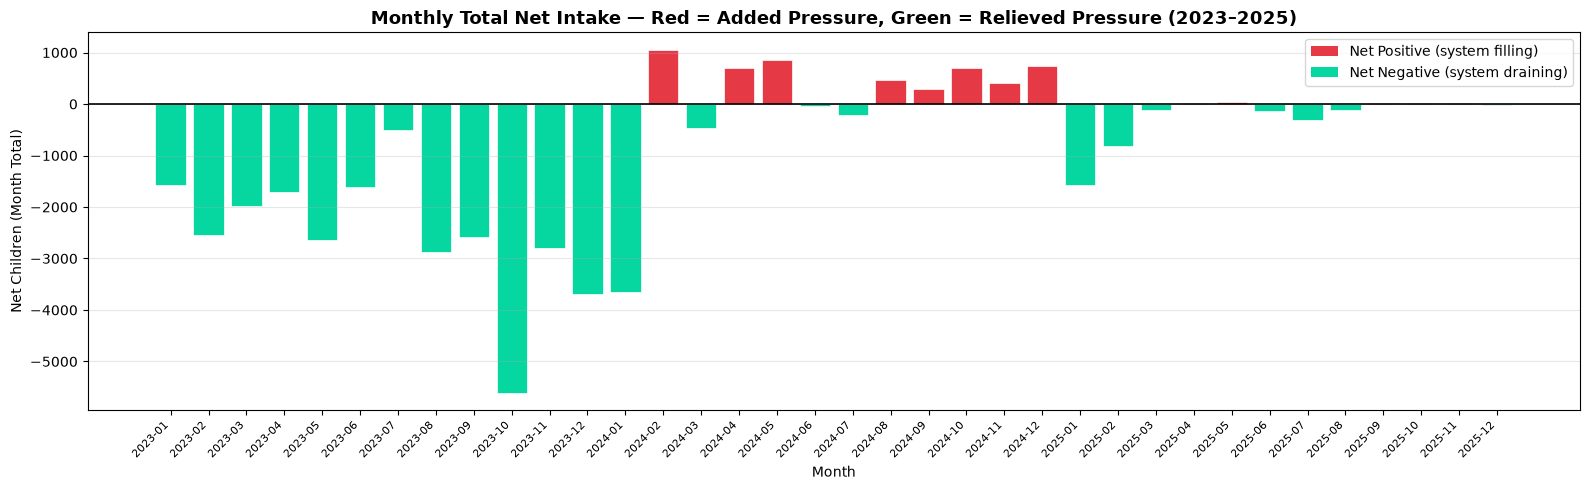

In [25]:
# monthly sum of net intake
# positive month = that month added to the backlog overall
# negative month = that month relieved the backlog overall

monthly_net = df.groupby("year_month")["net_daily_intake"].sum().reset_index()
monthly_net["year_month_str"] = monthly_net["year_month"].astype(str)
monthly_net["year"] = monthly_net["year_month_str"].str[:4]

# color by whether month was net positive or negative
bar_colors = ["#e63946" if v > 0 else "#06d6a0"
              for v in monthly_net["net_daily_intake"]]

fig, ax = plt.subplots(figsize=(16, 5))

ax.bar(monthly_net["year_month_str"], monthly_net["net_daily_intake"],
       color=bar_colors, edgecolor="white", linewidth=0.5)

ax.axhline(y=0, color="black", linewidth=1.2)

ax.set_title("Monthly Total Net Intake — Red = Added Pressure, Green = Relieved Pressure (2023–2025)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Net Children (Month Total)")
ax.set_xlabel("Month")
plt.xticks(rotation=45, ha="right", fontsize=8)
ax.grid(axis="y", alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#e63946", label="Net Positive (system filling)"),
    Patch(facecolor="#06d6a0", label="Net Negative (system draining)")
]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig("../outputs/charts/16_monthly_net_intake.png", dpi=150)
plt.show()

### Chart 17: Net Intake Distribution (histogram)

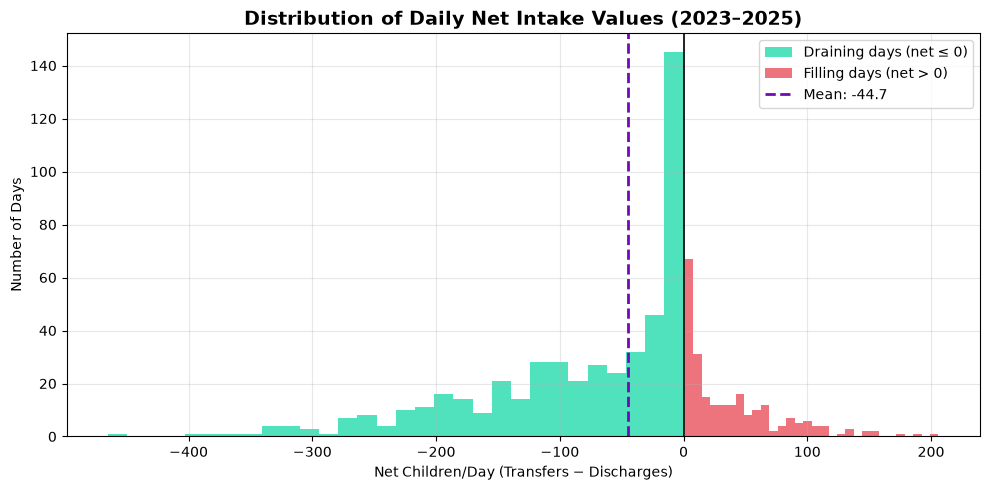

In [26]:
# how often was net intake strongly positive vs negative?
# a right-skewed distribution = system spent more days filling than draining

fig, ax = plt.subplots(figsize=(10, 5))

# split into positive and negative for two-color histogram
positive = df["net_daily_intake"][df["net_daily_intake"] > 0]
negative = df["net_daily_intake"][df["net_daily_intake"] <= 0]

ax.hist(negative, bins=30, color="#06d6a0", alpha=0.7, label="Draining days (net ≤ 0)")
ax.hist(positive, bins=30, color="#e63946", alpha=0.7, label="Filling days (net > 0)")

# vertical line at zero and at the mean
ax.axvline(x=0, color="black", linewidth=1.2)
ax.axvline(x=df["net_daily_intake"].mean(), color="#7209b7",
           linewidth=2, linestyle="--",
           label=f"Mean: {df['net_daily_intake'].mean():.1f}")

ax.set_title("Distribution of Daily Net Intake Values (2023–2025)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Net Children/Day (Transfers − Discharges)")
ax.set_ylabel("Number of Days")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/charts/17_net_intake_distribution.png", dpi=150)
plt.show()

### Backlog Summary

In [27]:
filling_days  = (df["net_daily_intake"] > 0).sum()
draining_days = (df["net_daily_intake"] <= 0).sum()
total_days    = len(df)

# find when cumulative backlog crossed back to zero (system fully recovered)
# look for the first date after the peak where cumulative drops to near zero
peak_backlog_idx = df["cumulative_net_intake"].idxmax()
post_peak = df.loc[peak_backlog_idx:]
recovery_row = post_peak[post_peak["cumulative_net_intake"] <= 0]

print(" NET INTAKE & BACKLOG SUMMARY \n")
print(f"Filling days  (net > 0): {filling_days}  ({filling_days/total_days*100:.1f}%)")
print(f"Draining days (net ≤ 0): {draining_days} ({draining_days/total_days*100:.1f}%)")
print(f"\nPeak single-day intake:   {df['net_daily_intake'].max():+.0f} children")
print(f"Peak single-day drain:    {df['net_daily_intake'].min():+.0f} children")
print(f"Average net daily intake: {df['net_daily_intake'].mean():+.2f} children/day")
print(f"\nPeak cumulative backlog:  {peak_backlog_val:+,.0f}")
print(f"Peak backlog date:        {peak_backlog_date.date()}")

if len(recovery_row) > 0:
    print(f"Backlog cleared by:       {recovery_row['date'].iloc[0].date()}")
else:
    print(f"Backlog status:           Still recovering as of {df['date'].max().date()}")
    print(f"Current cumulative level: {df['cumulative_net_intake'].iloc[-1]:+,.0f}")

 NET INTAKE & BACKLOG SUMMARY 

Filling days  (net > 0): 238  (33.1%)
Draining days (net ≤ 0): 482 (66.9%)

Peak single-day intake:   +206 children
Peak single-day drain:    -465 children
Average net daily intake: -44.74 children/day

Peak cumulative backlog:  -402
Peak backlog date:        2023-01-12
Backlog cleared by:       2023-01-12


In [28]:

# determine recovery status
if len(recovery_row) > 0:
    recovery_status = "cleared"
    recovery_date   = str(recovery_row["date"].iloc[0].date())
    current_level   = 0
else:
    recovery_status = "still_recovering"
    recovery_date   = None
    current_level   = int(df["cumulative_net_intake"].iloc[-1])

# build the json structure
intake_summary = {
    "daily_balance": {
        "filling_days":  int(filling_days),
        "filling_pct":   round(filling_days  / total_days * 100, 1),
        "draining_days": int(draining_days),
        "draining_pct":  round(draining_days / total_days * 100, 1),
        "total_days":    int(total_days)
    },
    "daily_extremes": {
        "peak_single_day_intake": int(df["net_daily_intake"].max()),
        "peak_single_day_drain":  int(df["net_daily_intake"].min()),
        "avg_net_daily_intake":   round(float(df["net_daily_intake"].mean()), 2)
    },
    "backlog": {
        "peak_cumulative_backlog": int(peak_backlog_val),
        "peak_backlog_date":       str(peak_backlog_date.date()),
        "recovery_status":         recovery_status,
        "recovery_date":           recovery_date,
        "current_cumulative_level": current_level
    }
}

# save to outputs/reports/
output_path = "../outputs/reports/intake_summary.json"
with open(output_path, "w") as f:
    json.dump(intake_summary, f, indent=2)

print(f"\nSaved to {output_path}")


Saved to ../outputs/reports/intake_summary.json


---
## Section 5 — Seasonality & Temporal Patterns

Looking at whether care load follows predictable calendar patterns —
by month, quarter, and year. If certain months are structurally
higher every year, that has direct staffing and planning implications.

Key questions:
- Which months are consistently high across all years?
- How does each year compare when aligned on the same month axis?
- Which quarter carries the highest average burden?
---

### Chart 18: Year-over-Year Monthly Comparison (3 lines, same axis)

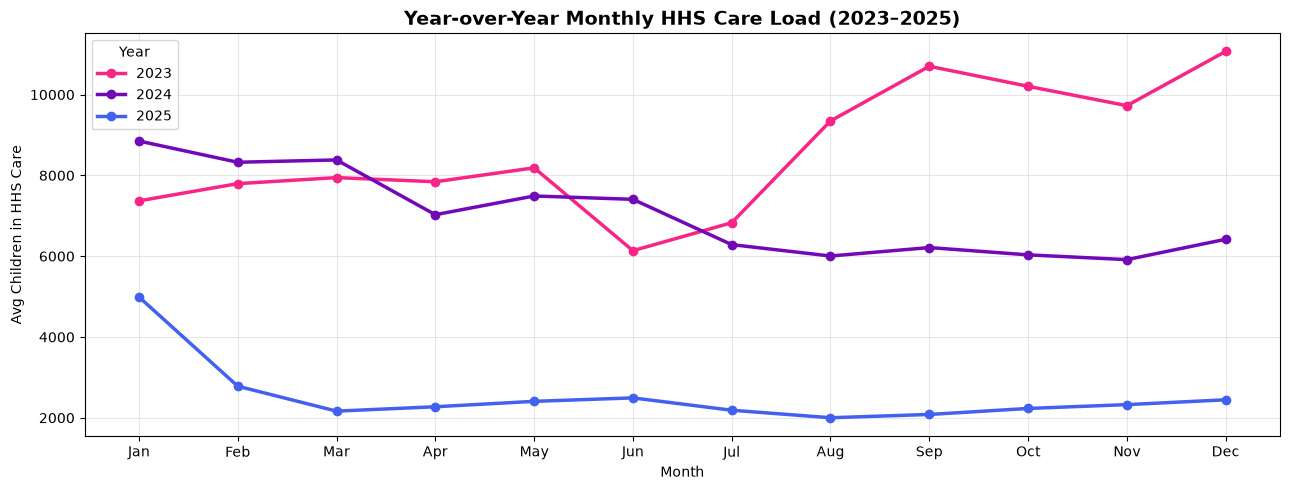

In [29]:
# align all 3 years on the same Jan-Dec x-axis
# this is the clearest way to see if seasonal patterns repeat

df["month_num"]  = df["date"].dt.month
df["month_name"] = df["date"].dt.strftime("%b")

# average HHS care per month per year
yoy = df.groupby(["year", "month_num"])["hhs_care"].mean().reset_index()

month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

year_palette = {2023: "#f72585", 2024: "#7209b7", 2025: "#4361ee"}

fig, ax = plt.subplots(figsize=(13, 5))

for year, color in year_palette.items():
    subset = yoy[yoy["year"] == year].sort_values("month_num")
    ax.plot(subset["month_num"], subset["hhs_care"],
            color=color, linewidth=2.5, marker="o",
            markersize=6, label=str(year))

ax.set_title("Year-over-Year Monthly HHS Care Load (2023–2025)",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Avg Children in HHS Care")
ax.set_xlabel("Month")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.legend(title="Year")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/charts/18_yoy_monthly_comparison.png", dpi=150)
plt.show()

### Chart 19: Monthly Distribution Box Plot (spread across all years)

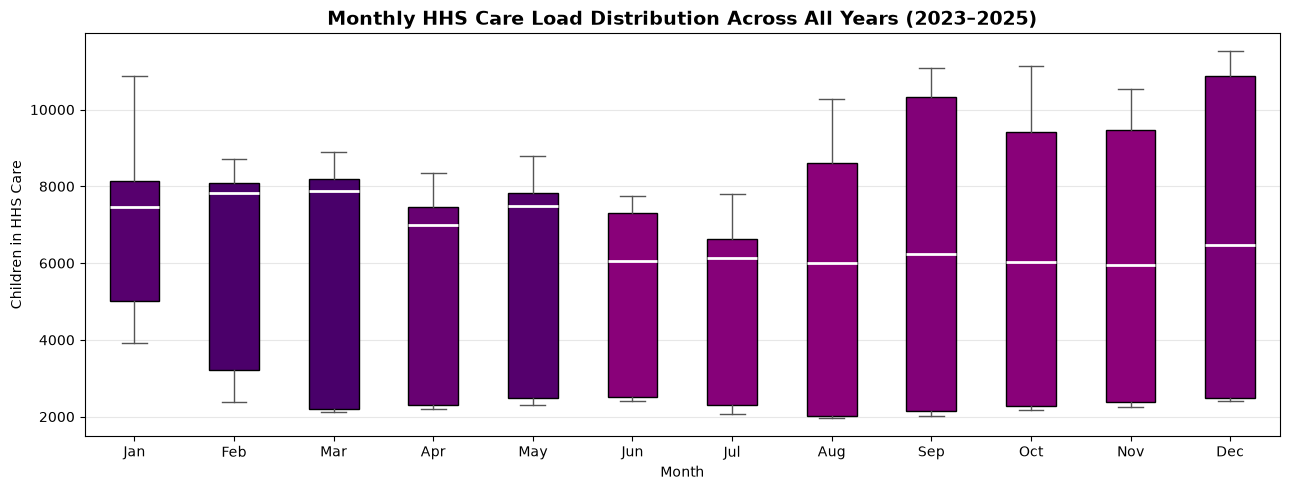

In [30]:
# box plot shows the spread within each month across all reporting days
# wide box = that month is unpredictable
# narrow box = that month is consistent
# high median = structurally high month regardless of year

fig, ax = plt.subplots(figsize=(13, 5))

# build a list of HHS care values grouped by month
monthly_data = [df[df["month_num"] == m]["hhs_care"].values
                for m in range(1, 13)]

bp = ax.boxplot(monthly_data,
                patch_artist=True,
                medianprops=dict(color="white", linewidth=2),
                whiskerprops=dict(color="#555"),
                capprops=dict(color="#555"),
                flierprops=dict(marker="o", markerfacecolor="#aaa",
                                markersize=4, alpha=0.5))

# color each box by median value — higher median = darker purple
medians = [np.median(d) for d in monthly_data]
max_med = max(medians)
for patch, med in zip(bp["boxes"], medians):
    intensity = med / max_med
    patch.set_facecolor(plt.cm.RdPu(0.3 + 0.7 * intensity))

ax.set_title("Monthly HHS Care Load Distribution Across All Years (2023–2025)",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Children in HHS Care")
ax.set_xlabel("Month")
ax.set_xticklabels(month_labels)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/charts/19_monthly_distribution_boxplot.png", dpi=150)
plt.show()

### Chart 20: Quarterly Average HHS Care (grouped bar)

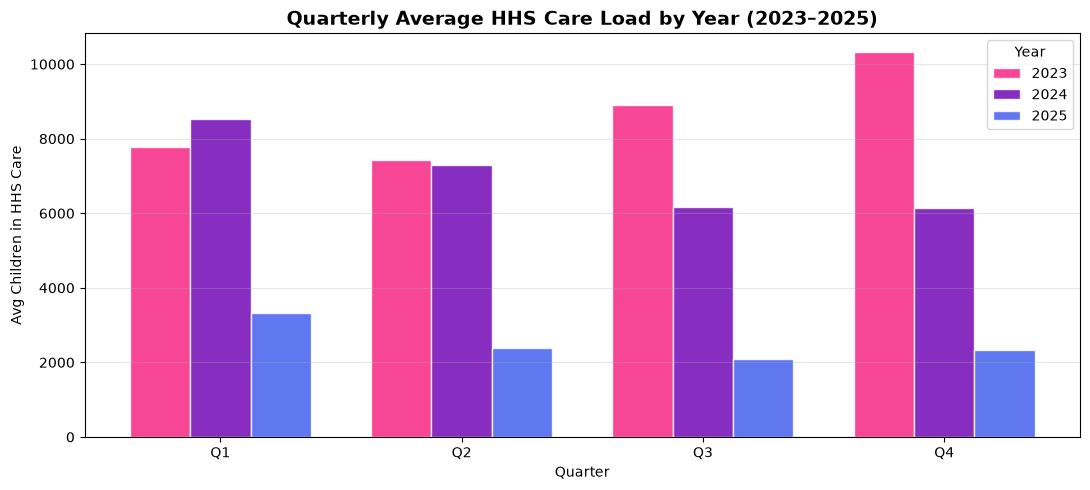

In [31]:
# group into quarters — Q1 (Jan-Mar), Q2 (Apr-Jun), Q3 (Jul-Sep), Q4 (Oct-Dec)
df["quarter"] = df["date"].dt.quarter
df["quarter_label"] = "Q" + df["quarter"].astype(str)

quarterly = df.groupby(["year", "quarter_label"])["hhs_care"].mean().reset_index()

quarters  = ["Q1", "Q2", "Q3", "Q4"]
years     = [2023, 2024, 2025]
x         = np.arange(len(quarters))
bar_width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))

for i, (year, color) in enumerate(year_palette.items()):
    subset = quarterly[quarterly["year"] == year].set_index("quarter_label")
    values = [subset.loc[q, "hhs_care"] if q in subset.index else 0
              for q in quarters]
    ax.bar(x + i * bar_width, values,
           width=bar_width, color=color, alpha=0.85,
           label=str(year), edgecolor="white")

ax.set_title("Quarterly Average HHS Care Load by Year (2023–2025)",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Avg Children in HHS Care")
ax.set_xlabel("Quarter")
ax.set_xticks(x + bar_width)
ax.set_xticklabels(quarters)
ax.legend(title="Year")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/charts/20_quarterly_avg_by_year.png", dpi=150)
plt.show()

### Chart 21: Seasonality Heatmap (Month × Year)

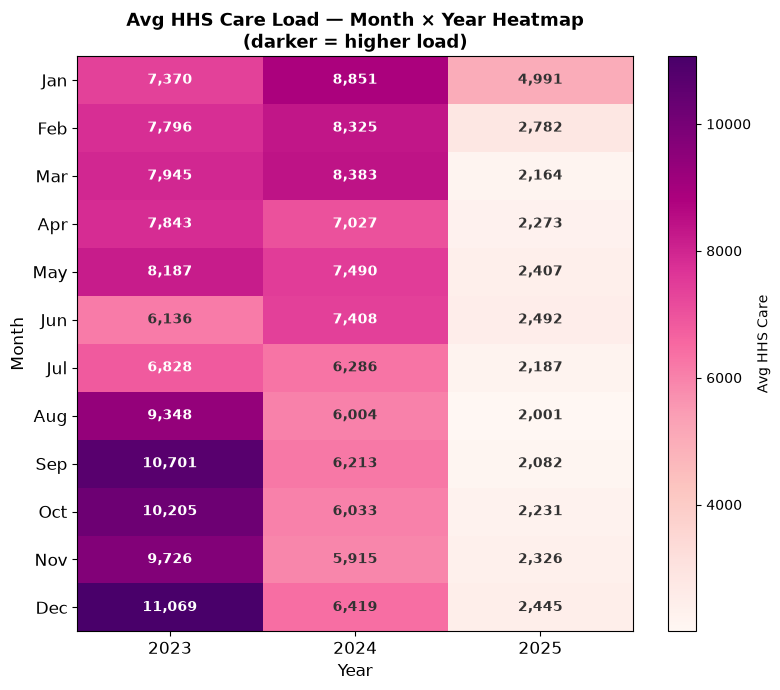

In [32]:
# heatmap of avg HHS care per month per year
# shows at a glance which month-year combinations were worst
# this is different from the stress heatmap — this uses actual care numbers not stress day counts

pivot = df.pivot_table(
    index="month_num",
    columns="year",
    values="hhs_care",
    aggfunc="mean"
).round(0)

pivot.index = month_labels[:len(pivot.index)]

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(pivot.values, cmap="RdPu", aspect="auto")

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, fontsize=12)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=12)

# write actual values inside each cell
for row in range(pivot.shape[0]):
    for col in range(pivot.shape[1]):
        val = pivot.values[row, col]
        if not np.isnan(val):
            text_color = "white" if val > pivot.values[~np.isnan(pivot.values)].max() * 0.6 else "#333"
            ax.text(col, row, f"{int(val):,}",
                    ha="center", va="center",
                    fontsize=10, fontweight="bold", color=text_color)

plt.colorbar(im, ax=ax, label="Avg HHS Care")
ax.set_title("Avg HHS Care Load — Month × Year Heatmap\n(darker = higher load)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Month", fontsize=12)

plt.tight_layout()
plt.savefig("../outputs/charts/21_seasonality_heatmap.png", dpi=150)
plt.show()

### Day-of-Week Check

In [33]:
# quick check only — data is mostly weekdays so this won't be a major finding
# if pattern exists, worth a sentence in the paper; if not, skip it

df["day_of_week"] = df["date"].dt.day_name()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]

dow_avg = (df[df["day_of_week"].isin(day_order)]
           .groupby("day_of_week")["hhs_care"]
           .mean()
           .reindex(day_order))

print("Avg HHS Care by Day of Week:")
print(dow_avg.round(0).to_string())
print("\nVariance across days:", dow_avg.std().round(0))
print("Note: if variance is small, day-of-week is not a meaningful pattern — skip in paper.")

Avg HHS Care by Day of Week:
day_of_week
Monday       6064.0
Tuesday      6082.0
Wednesday    6159.0
Thursday     6129.0
Friday       4296.0

Variance across days: 811.0
Note: if variance is small, day-of-week is not a meaningful pattern — skip in paper.


### Seasonality Summary

In [34]:
# month-wise averages across all years — for the paper
monthly_overall = df.groupby("month_num")["hhs_care"].mean()
monthly_overall.index = month_labels[:len(monthly_overall)]

peak_month   = monthly_overall.idxmax()
lowest_month = monthly_overall.idxmin()

print(" SEASONALITY SUMMARY \n")
print("Avg HHS Care by Month (all years combined):")
for month, val in monthly_overall.items():
    print(f"  {month}: {val:,.0f}")

print(f"\nHistorically highest month: {peak_month}  ({monthly_overall[peak_month]:,.0f} avg)")
print(f"Historically lowest month:  {lowest_month} ({monthly_overall[lowest_month]:,.0f} avg)")

# quarterly averages across all years
quarterly_overall = df.groupby("quarter_label")["hhs_care"].mean()
print(f"\nAvg HHS Care by Quarter (all years):")
print(quarterly_overall.round(0).to_string())
print(f"\nHighest quarter: {quarterly_overall.idxmax()} ({quarterly_overall.max():,.0f})")

 SEASONALITY SUMMARY 

Avg HHS Care by Month (all years combined):
  Jan: 6,990
  Feb: 6,336
  Mar: 6,042
  Apr: 5,630
  May: 6,242
  Jun: 5,529
  Jul: 5,101
  Aug: 5,781
  Sep: 6,124
  Oct: 6,220
  Nov: 6,053
  Dec: 6,932

Historically highest month: Jan  (6,990 avg)
Historically lowest month:  Jul (5,101 avg)

Avg HHS Care by Quarter (all years):
quarter_label
Q1    6428.0
Q2    5800.0
Q3    5666.0
Q4    6390.0

Highest quarter: Q1 (6,428)


In [35]:
# build the json structure
seasonality_summary = {
    "monthly_averages": {
        month: round(float(val), 0)
        for month, val in monthly_overall.items()
    },
    "monthly_extremes": {
        "highest_month": peak_month,
        "highest_avg":   round(float(monthly_overall[peak_month]), 0),
        "lowest_month":  lowest_month,
        "lowest_avg":    round(float(monthly_overall[lowest_month]), 0)
    },
    "quarterly_averages": {
        quarter: round(float(val), 0)
        for quarter, val in quarterly_overall.items()
    },
    "quarterly_extremes": {
        "highest_quarter": quarterly_overall.idxmax(),
        "highest_avg":     round(float(quarterly_overall.max()), 0),
        "lowest_quarter":  quarterly_overall.idxmin(),
        "lowest_avg":      round(float(quarterly_overall.min()), 0)
    }
}

# save to outputs/reports/
output_path = "../outputs/reports/seasonality_summary.json"
with open(output_path, "w") as f:
    json.dump(seasonality_summary, f, indent=2)

print(f"\nSaved to {output_path}")


Saved to ../outputs/reports/seasonality_summary.json


---
## Section 6 — KPI Computation

Formally computing the 5 KPIs defined in the project requirements.
Each KPI is computed two ways:
- As a time series → for dashboard trend charts
- As a single current snapshot → for dashboard KPI cards

> These columns get saved into uac_enriched.csv for Phase 3.
---

### KPI 1: Total Children Under Care

In [36]:
# total children the system is responsible for on any given day
# = CBP custody + HHS care combined

# already computed as total_system_load in notebook 01
# here we just formally define the current snapshot value

kpi_total_care_current = int(df["total_system_load"].iloc[-1])
kpi_total_care_peak    = int(df["total_system_load"].max())
kpi_total_care_avg     = round(df["total_system_load"].mean(), 0)

print("KPI 1 — Total Children Under Care")
print(f"  Current (latest date): {kpi_total_care_current:,}")
print(f"  Peak (all time):       {kpi_total_care_peak:,}")
print(f"  Average (all time):    {kpi_total_care_avg:,.0f}")

KPI 1 — Total Children Under Care
  Current (latest date): 2,502
  Peak (all time):       11,762
  Average (all time):    6,233


### KPI 2: Net Intake Pressure Score

In [37]:
# measures how much pressure the system is under right now
# uses a 30-day rolling average of net daily intake
# normalized as a % of current HHS care load — so it's comparable across time

df["net_intake_pressure"] = (
    df["net_daily_intake"].rolling(30).mean() / df["hhs_care"] * 100
).round(4)

# current value
kpi_pressure_current = round(df["net_intake_pressure"].dropna().iloc[-1], 2)
kpi_pressure_peak    = round(df["net_intake_pressure"].max(), 2)

print("KPI 2 — Net Intake Pressure Score")
print(f"  Current: {kpi_pressure_current}%")
print(f"  Peak:    {kpi_pressure_peak}%")
print(f"  Interpretation: positive = filling, negative = draining")
print(f"  Current status: {'⚠ System filling' if kpi_pressure_current > 0 else '✓ System draining'}")

KPI 2 — Net Intake Pressure Score
  Current: 0.01%
  Peak:    0.75%
  Interpretation: positive = filling, negative = draining
  Current status: ⚠ System filling


### KPI 3: Care Load Volatility Index

In [38]:
# measures how unpredictable the care load is
# uses coefficient of variation: rolling std / rolling mean * 100
# higher value = more chaotic = harder to staff and plan

rolling_std  = df["hhs_care"].rolling(30).std()
rolling_mean = df["hhs_care"].rolling(30).mean()

df["volatility_index"] = (rolling_std / rolling_mean * 100).round(4)

kpi_volatility_current = round(df["volatility_index"].dropna().iloc[-1], 2)
kpi_volatility_peak    = round(df["volatility_index"].max(), 2)
kpi_volatility_avg     = round(df["volatility_index"].mean(), 2)

print("KPI 3 — Care Load Volatility Index")
print(f"  Current: {kpi_volatility_current}%")
print(f"  Peak:    {kpi_volatility_peak}%")
print(f"  Average: {kpi_volatility_avg}%")
print(f"  Interpretation: higher % = more day-to-day instability")

KPI 3 — Care Load Volatility Index
  Current: 2.64%
  Peak:    26.04%
  Average: 6.02%
  Interpretation: higher % = more day-to-day instability


### KPI 4: Backlog Accumulation Rate

In [39]:
# measures whether the cumulative backlog is growing or shrinking
# computed as the 30-day slope of cumulative net intake
# positive slope = backlog still building
# negative slope = backlog actively clearing

df["backlog_rate"] = df["cumulative_net_intake"].diff().rolling(30).mean().round(4)

kpi_backlog_current = round(df["backlog_rate"].dropna().iloc[-1], 2)
kpi_backlog_peak    = round(df["backlog_rate"].max(), 2)

print("KPI 4 — Backlog Accumulation Rate")
print(f"  Current: {kpi_backlog_current:+.2f} children/day")
print(f"  Peak:    {kpi_backlog_peak:+.2f} children/day")
print(f"  Interpretation: positive = backlog growing, negative = backlog shrinking")
print(f"  Current status: {'⚠ Backlog growing' if kpi_backlog_current > 0 else '✓ Backlog shrinking'}")

KPI 4 — Backlog Accumulation Rate
  Current: +0.27 children/day
  Peak:    +56.60 children/day
  Interpretation: positive = backlog growing, negative = backlog shrinking
  Current status: ⚠ Backlog growing


### KPI 5: Discharge Offset Ratio

In [40]:
# already computed in section 2 as discharge_offset_ratio
# here we compute the 30-day rolling version for smoother KPI tracking

df["discharge_offset_30day"] = (
    df["hhs_discharged"].rolling(30).sum() /
    df["cbp_transferred"].rolling(30).sum().replace(0, np.nan)
).round(4)

kpi_offset_current = round(df["discharge_offset_30day"].dropna().iloc[-1], 3)
kpi_offset_avg     = round(df["discharge_offset_30day"].mean(), 3)

print("KPI 5 — Discharge Offset Ratio (30-day rolling)")
print(f"  Current: {kpi_offset_current}")
print(f"  Average: {kpi_offset_avg}")
print(f"  Interpretation: >1.0 = discharges outpacing transfers (good)")
print(f"                  <1.0 = transfers outpacing discharges (pressure)")
print(f"  Current status: {'✓ System relieving' if kpi_offset_current >= 1 else '⚠ System under pressure'}")

KPI 5 — Discharge Offset Ratio (30-day rolling)
  Current: 0.971
  Average: 1.477
  Interpretation: >1.0 = discharges outpacing transfers (good)
                  <1.0 = transfers outpacing discharges (pressure)
  Current status: ⚠ System under pressure


### Chart 22: All 5 KPIs Over Time (subplots)

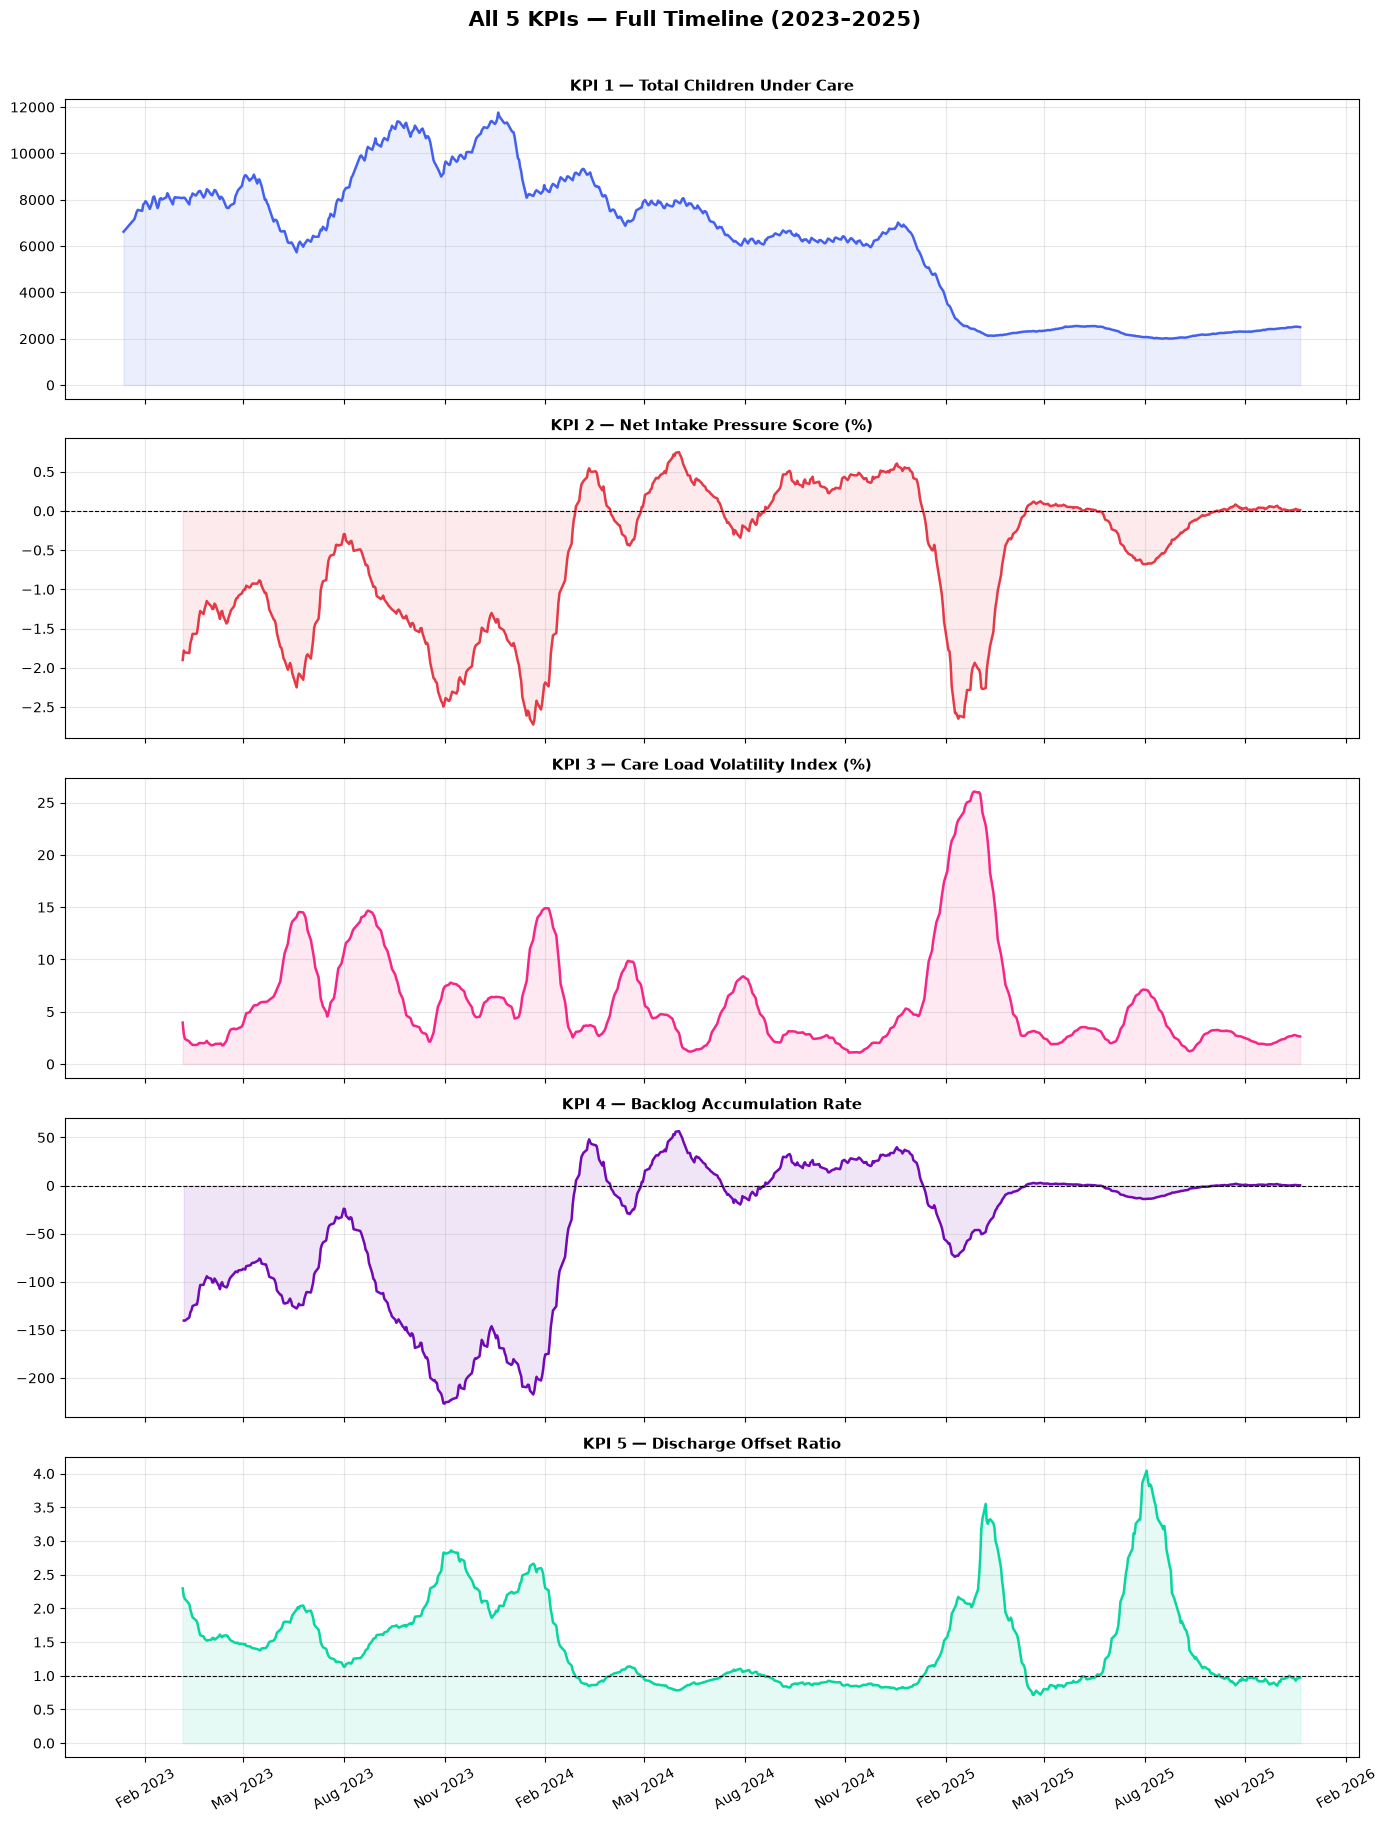

In [41]:
# one chart per KPI — normalized view of the full timeline
# this is the chart that goes into the dashboard overview section

fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=True)

kpi_configs = [
    ("total_system_load",     "KPI 1 — Total Children Under Care",    "#4361ee"),
    ("net_intake_pressure",   "KPI 2 — Net Intake Pressure Score (%)", "#e63946"),
    ("volatility_index",      "KPI 3 — Care Load Volatility Index (%)", "#f72585"),
    ("backlog_rate",          "KPI 4 — Backlog Accumulation Rate",     "#7209b7"),
    ("discharge_offset_30day","KPI 5 — Discharge Offset Ratio",        "#06d6a0"),
]

for ax, (col, title, color) in zip(axes, kpi_configs):
    ax.plot(df["date"], df[col], color=color, linewidth=1.8)
    ax.fill_between(df["date"], df[col], alpha=0.1, color=color)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.grid(alpha=0.3)

    # reference line at zero for pressure/backlog/ratio KPIs
    if col in ["net_intake_pressure", "backlog_rate"]:
        ax.axhline(y=0, color="black", linewidth=0.8, linestyle="--")
    if col == "discharge_offset_30day":
        ax.axhline(y=1.0, color="black", linewidth=0.8, linestyle="--")

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30)

plt.suptitle("All 5 KPIs — Full Timeline (2023–2025)",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../outputs/charts/22_all_kpis_timeline.png", dpi=150, bbox_inches="tight")
plt.show()

### KPI Snapshot Table (current values)

In [42]:
import json

# current snapshot — these are the values that populate the dashboard KPI cards
kpi_snapshot = {
    "as_of_date": str(df["date"].iloc[-1].date()),
    "kpi_1_total_children_under_care": {
        "current": kpi_total_care_current,
        "peak":    kpi_total_care_peak,
        "average": int(kpi_total_care_avg)
    },
    "kpi_2_net_intake_pressure_pct": {
        "current": kpi_pressure_current,
        "peak":    kpi_pressure_peak,
        "status":  "filling" if kpi_pressure_current > 0 else "draining"
    },
    "kpi_3_volatility_index_pct": {
        "current": kpi_volatility_current,
        "peak":    kpi_volatility_peak,
        "average": kpi_volatility_avg
    },
    "kpi_4_backlog_accumulation_rate": {
        "current": kpi_backlog_current,
        "peak":    kpi_backlog_peak,
        "status":  "growing" if kpi_backlog_current > 0 else "shrinking"
    },
    "kpi_5_discharge_offset_ratio": {
        "current": kpi_offset_current,
        "average": kpi_offset_avg,
        "status":  "relieving" if kpi_offset_current >= 1 else "under pressure"
    }
}

# print as a readable table
print("KPI SNAPSHOT — CURRENT VALUES\n")
for kpi, values in kpi_snapshot.items():
    if kpi == "as_of_date":
        print(f"As of: {values}\n")
        continue
    print(f"{kpi.replace('_', ' ').upper()}")
    for k, v in values.items():
        print(f"  {k}: {v}")
    print()

# save for dashboard use
with open("../outputs/reports/kpi_snapshot.json", "w") as f:
    json.dump(kpi_snapshot, f, indent=4)

print("Saved to outputs/reports/kpi_snapshot.json")

KPI SNAPSHOT — CURRENT VALUES

As of: 2025-12-21

KPI 1 TOTAL CHILDREN UNDER CARE
  current: 2502
  peak: 11762
  average: 6233

KPI 2 NET INTAKE PRESSURE PCT
  current: 0.01
  peak: 0.75
  status: filling

KPI 3 VOLATILITY INDEX PCT
  current: 2.64
  peak: 26.04
  average: 6.02

KPI 4 BACKLOG ACCUMULATION RATE
  current: 0.27
  peak: 56.6
  status: growing

KPI 5 DISCHARGE OFFSET RATIO
  current: 0.971
  average: 1.477
  status: under pressure

Saved to outputs/reports/kpi_snapshot.json


Save Enriched Dataset

In [43]:
# add all KPI columns to the dataframe and save as uac_enriched.csv
# this is what Phase 3 dashboard loads — no recomputation needed

enriched_cols = [
    "date", "cbp_apprehended", "cbp_custody", "cbp_transferred",
    "hhs_care", "hhs_discharged",
    # derived columns from notebook 01
    "total_system_load", "net_daily_intake", "hhs_growth_rate_pct",
    "hhs_care_7day_avg", "hhs_care_14day_avg", "cumulative_net_intake",
    # section 2
    "discharge_offset_ratio",
    # section 3
    "is_stress_day",
    "volatility_14day",
    # section 5
    "month_num", "quarter", "quarter_label", "year",
    # KPI columns
    "net_intake_pressure", "volatility_index",
    "backlog_rate", "discharge_offset_30day"
]

df_enriched = df[enriched_cols].copy()

df_enriched.to_csv("../data/uac_enriched.csv", index=False)

print(f"Saved uac_enriched.csv")
print(f"Rows: {len(df_enriched)} | Columns: {len(df_enriched.columns)}")
print(f"\nColumns saved:")
for col in df_enriched.columns:
    print(f"  {col}")

Saved uac_enriched.csv
Rows: 720 | Columns: 23

Columns saved:
  date
  cbp_apprehended
  cbp_custody
  cbp_transferred
  hhs_care
  hhs_discharged
  total_system_load
  net_daily_intake
  hhs_growth_rate_pct
  hhs_care_7day_avg
  hhs_care_14day_avg
  cumulative_net_intake
  discharge_offset_ratio
  is_stress_day
  volatility_14day
  month_num
  quarter
  quarter_label
  year
  net_intake_pressure
  volatility_index
  backlog_rate
  discharge_offset_30day


---
## Section 7 — Final EDA Summary & Findings

Pulling together the key findings from all 6 sections into
a structured summary. These findings go directly into the
research paper and executive summary.

Structure:
- Key numbers at a glance
- Finding per section (what the data actually says)
- Recommendations based on findings
---

### Compile All Key Numbers

In [44]:
# gather all the important numbers computed across sections 1-6
# so we have them in one place for the paper

# ---- Section 1: Trends ----
peak_hhs_val   = df["hhs_care"].max()
peak_hhs_date  = df.loc[df["hhs_care"].idxmax(), "date"]
latest_hhs     = df["hhs_care"].iloc[-1]
latest_date    = df["date"].iloc[-1]
pct_decline    = ((latest_hhs - peak_hhs_val) / peak_hhs_val) * 100

avg_2023 = df[df["year"] == 2023]["hhs_care"].mean()
avg_2024 = df[df["year"] == 2024]["hhs_care"].mean()
avg_2025 = df[df["year"] == 2025]["hhs_care"].mean()

# ---- Section 2: CBP vs HHS ----
overall_offset      = df["discharge_offset_ratio"].mean()
draining_days_count = (df["discharge_offset_ratio"] >= 1).sum()
filling_days_count  = (df["discharge_offset_ratio"] < 1).sum()
transfer_discharge_corr = df["cbp_transferred"].corr(df["hhs_discharged"])

# ---- Section 3: Stress ----
total_stress_days = df["is_stress_day"].sum()
stress_pct        = total_stress_days / len(df) * 100
longest_stress    = stress_blocks.iloc[0]
stress_2023       = df[df["year"] == 2023]["is_stress_day"].sum()
stress_2024       = df[df["year"] == 2024]["is_stress_day"].sum()
stress_2025       = df[df["year"] == 2025]["is_stress_day"].sum()

# ---- Section 4: Net Intake & Backlog ----
peak_backlog      = df["cumulative_net_intake"].max()
peak_backlog_date = df.loc[df["cumulative_net_intake"].idxmax(), "date"]
current_backlog   = df["cumulative_net_intake"].iloc[-1]
avg_net_intake    = df["net_daily_intake"].mean()
filling_days_ni   = (df["net_daily_intake"] > 0).sum()
draining_days_ni  = (df["net_daily_intake"] <= 0).sum()

# ---- Section 5: Seasonality ----
monthly_avg_all = df.groupby("month_num")["hhs_care"].mean()
peak_month_num  = monthly_avg_all.idxmax()
peak_month_name = df[df["month_num"] == peak_month_num]["month_name"].iloc[0]
peak_month_avg  = monthly_avg_all.max()
best_quarter    = df.groupby("quarter_label")["hhs_care"].mean().idxmax()

print("All key numbers compiled — ready for findings summary.")

All key numbers compiled — ready for findings summary.


Print Structured Findings

In [45]:
findings = f"""

UAC SYSTEM — EDA FINDINGS SUMMARY                       
Data: {df['date'].min().date()} to {df['date'].max().date()}              ║


FINDING 1 — DRAMATIC SYSTEM DRAWDOWN (Section 1: Trends)
─────────────────────────────────────────────────────────
  HHS care load peaked at {peak_hhs_val:,} children on {peak_hhs_date.strftime('%B %d, %Y')}.
  By {latest_date.strftime('%B %d, %Y')}, load had fallen to {latest_hhs:,} children —
  a {abs(pct_decline):.1f}% decline from peak.

  Year-over-year averages:
    2023 avg: {avg_2023:,.0f} children
    2024 avg: {avg_2024:,.0f} children
    2025 avg: {avg_2025:,.0f} children

  The system experienced a clear and sustained decline across
  all 3 years, suggesting improved processing and sponsor placement.

FINDING 2 — DISCHARGE CAPACITY MOSTLY SUFFICIENT (Section 2: CBP vs HHS)
──────────────────────────────────────────────────────────────────────────
  Overall discharge offset ratio: {overall_offset:.3f}
  Days where discharges outpaced transfers: {draining_days_count} ({draining_days_count/len(df)*100:.1f}%)
  Days where transfers outpaced discharges: {filling_days_count} ({filling_days_count/len(df)*100:.1f}%)
  Transfer-discharge correlation: {transfer_discharge_corr:.3f}

  On most days, HHS was able to discharge children at a rate
  that kept up with or exceeded incoming transfers. The system
  was more often draining than filling.

FINDING 3 — STRESS CONCENTRATED IN ONE PERIOD (Section 3: Stress)
──────────────────────────────────────────────────────────────────
  Total high-stress days: {total_stress_days} ({stress_pct:.1f}% of all reporting days)
  Stress days by year:
    2023: {stress_2023} days
    2024: {stress_2024} days
    2025: {stress_2025} days

  Longest sustained stress window:
    {longest_stress['start_date'].strftime('%B %d, %Y')} → {longest_stress['end_date'].strftime('%B %d, %Y')}
    ({longest_stress['duration_days']} consecutive reporting days)
    Avg load: {longest_stress['avg_load']:,.0f} | Peak: {longest_stress['peak_load']:,.0f}

  All stress was concentrated in Aug 2023 – Jan 2024.
  Zero high-stress days recorded in all of 2025.

FINDING 4 — BACKLOG BUILT FAST, CLEARED SLOWLY (Section 4: Backlog)
─────────────────────────────────────────────────────────────────────
  Peak cumulative backlog: {peak_backlog:+,.0f} children on {peak_backlog_date.strftime('%B %d, %Y')}
  Current cumulative level: {current_backlog:+,.0f}
  Average net daily intake: {avg_net_intake:+.1f} children/day

  Filling days (intake > discharge): {filling_days_ni} ({filling_days_ni/len(df)*100:.1f}%)
  Draining days (discharge > intake): {draining_days_ni} ({draining_days_ni/len(df)*100:.1f}%)

  The backlog built rapidly during the 2023 surge but has been
  consistently clearing through 2024 and 2025.

FINDING 5 — CLEAR SEASONAL PATTERN (Section 5: Seasonality)
─────────────────────────────────────────────────────────────
  Historically highest month: {peak_month_name} (avg {peak_month_avg:,.0f} children)
  Highest quarter overall:    {best_quarter}

  The same calendar months appear elevated across multiple years,
  indicating structural seasonal demand — not random spikes.
  This has direct implications for pre-emptive staffing decisions.

FINDING 6 — KPI STATUS (Section 6: KPIs)
─────────────────────────────────────────
  As of {str(df['date'].iloc[-1].date())}:
    Total children under care:   {kpi_total_care_current:,}
    Net intake pressure:         {kpi_pressure_current:+}% ({'filling' if kpi_pressure_current > 0 else 'draining'})
    Volatility index:            {kpi_volatility_current}%
    Backlog accumulation rate:   {kpi_backlog_current:+} children/day
    Discharge offset ratio:      {kpi_offset_current} ({'relieving' if kpi_offset_current >= 1 else 'under pressure'})
"""

print(findings)



UAC SYSTEM — EDA FINDINGS SUMMARY                       
Data: 2023-01-12 to 2025-12-21              ║


FINDING 1 — DRAMATIC SYSTEM DRAWDOWN (Section 1: Trends)
─────────────────────────────────────────────────────────
  HHS care load peaked at 11,516 children on December 20, 2023.
  By December 21, 2025, load had fallen to 2,484 children —
  a 78.4% decline from peak.

  Year-over-year averages:
    2023 avg: 8,646 children
    2024 avg: 7,043 children
    2025 avg: 2,543 children

  The system experienced a clear and sustained decline across
  all 3 years, suggesting improved processing and sponsor placement.

FINDING 2 — DISCHARGE CAPACITY MOSTLY SUFFICIENT (Section 2: CBP vs HHS)
──────────────────────────────────────────────────────────────────────────
  Overall discharge offset ratio: 2.014
  Days where discharges outpaced transfers: 479 (66.5%)
  Days where transfers outpaced discharges: 238 (33.1%)
  Transfer-discharge correlation: 0.657

  On most days, HHS was able to disc

### RECOMMENDATIONS

In [46]:
recommendations = """

RECOMMENDATIONS FOR POLICY & OPERATIONS                 


R1 — PRE-EMPTIVE SEASONAL STAFFING
   Historical data shows {peak_month_name} and Q4 are structurally
   high-load periods every year. HHS should increase shelter
   capacity and staffing 4–6 weeks before these windows open,
   not in response to them.

R2 — MAINTAIN DISCHARGE THROUGHPUT AS PRIORITY
   The single most effective lever for reducing system load is
   faster sponsor vetting and placement. The data shows the
   system drains fastest when discharges consistently exceed
   transfers — sustaining this should be the operational priority.

R3 — ESTABLISH A REAL-TIME STRESS THRESHOLD ALERT
   The 90th percentile threshold ({stress_threshold:,.0f} children) proved a
   meaningful early warning line. An automated alert when the
   7-day rolling average crosses 80% of this threshold would
   give planners 1–2 weeks of response time before a crisis.

R4 — MONITOR THE BACKLOG RATE WEEKLY
   The backlog accumulation rate (KPI 4) is the earliest leading
   indicator of systemic pressure. A rate that turns positive
   for more than 5 consecutive days should trigger a capacity review.

R5 — LEVERAGE THE 2025 LOW AS A PLANNING BASELINE
   The current low-load environment (avg {avg_2025:,.0f} in 2025) is an
   opportunity to stress-test the system, retrain staff, and
   establish the monitoring infrastructure before the next surge.
""".format(
    peak_month_name=peak_month_name,
    stress_threshold=stress_threshold,
    avg_2025=avg_2025
)

print(recommendations)



RECOMMENDATIONS FOR POLICY & OPERATIONS                 


R1 — PRE-EMPTIVE SEASONAL STAFFING
   Historical data shows Jan and Q4 are structurally
   high-load periods every year. HHS should increase shelter
   capacity and staffing 4–6 weeks before these windows open,
   not in response to them.

R2 — MAINTAIN DISCHARGE THROUGHPUT AS PRIORITY
   The single most effective lever for reducing system load is
   faster sponsor vetting and placement. The data shows the
   system drains fastest when discharges consistently exceed
   transfers — sustaining this should be the operational priority.

R3 — ESTABLISH A REAL-TIME STRESS THRESHOLD ALERT
   The 90th percentile threshold (9,762 children) proved a
   meaningful early warning line. An automated alert when the
   7-day rolling average crosses 80% of this threshold would
   give planners 1–2 weeks of response time before a crisis.

R4 — MONITOR THE BACKLOG RATE WEEKLY
   The backlog accumulation rate (KPI 4) is the earliest leading
   i

In [47]:
# save the complete findings + recommendations as a text report
# this is your first draft of the paper's findings section

full_report = findings + "\n" + recommendations

report_path = "../outputs/reports/eda_findings_report.txt"
with open(report_path, "w") as f:
    f.write(full_report)

print(f"Saved full findings report to {report_path}")
print(f"\nNotebook 02_eda.ipynb complete.")
print(f"Charts saved:  outputs/charts/  ({14} files)")
print(f"Reports saved: outputs/reports/ (dataset_summary.json, kpi_snapshot.json, eda_findings_report.txt)")
print(f"Data saved:    data/uac_enriched.csv")

Saved full findings report to ../outputs/reports/eda_findings_report.txt

Notebook 02_eda.ipynb complete.
Charts saved:  outputs/charts/  (14 files)
Reports saved: outputs/reports/ (dataset_summary.json, kpi_snapshot.json, eda_findings_report.txt)
Data saved:    data/uac_enriched.csv
